# E75 · Image segmentation with an unknown number of regions, checked against people

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: ten photographs from the **Berkeley Segmentation Dataset (BSDS500)** (Martin et al. 2001; Arbelaez et al. 2011) at half resolution, each with the segmentations of **5 or 6 people** who were asked to divide the picture into "things"; two from the training split (used only to choose one setting) and eight from the test split |
| **You will learn** | Segmentation as **clustering** of superpixels (SLIC, written in NumPy/Numba) with an **unknown number of segments** · a truncated **stick-breaking Dirichlet-process mixture** in PyMC, and why NUTS is the wrong tool for it (label switching, chains in different modes, a truncation that binds) · **label-invariant summaries** of a partition posterior: co-assignment probabilities, boundary probabilities, the posterior of K · a **Potts (Markov random field) prior** on the partition to make segments spatially coherent · a **collapsed Gibbs** sampler with conjugate Normal-inverse-Wishart clusters, **Swendsen-Wang** block moves and **parallel tempering**, checked against **exact enumeration** and on a **synthetic image with known truth** · what the Potts prior believes on its own (one segment, at almost any coupling) · a sampler **trap** and how to spot it · point estimates that minimise **Binder** and **variation-of-information** loss vs the MAP · **validation against people**: tolerance-matched precision/recall and F, **calibration** of boundary probabilities against the share of people who drew a boundary, and whether the model is unsure where people disagree · **a granularity ensemble**, and why posterior uncertainty at fixed settings is not the uncertainty people have · uncertainty displays: boundary-probability maps, "click a pixel" co-assignment maps, K with a representative segmentation for each value, hypothetical outcomes (a grid and an animation) |

## The setting

Draw lines around the "things" in a photograph. Five people given the same photograph and the same
instruction draw five different pictures: one outlines the lighthouse, the houses and the rocks;
another also outlines every window and the shadow under a cloud. None of them is wrong. **Image
segmentation has no single right answer**, and a method that returns one segmentation hides that.

A Bayesian model returns a **distribution over segmentations** (partitions of the pixels). That
raises three questions this example works through:

1. **How many segments?** Nobody knows in advance. A Dirichlet-process prior lets the data decide,
   and the posterior of K says how sure it is.
2. **How do you summarise a distribution over partitions?** Segment labels are arbitrary ("segment
   3" in one draw is "segment 7" in the next: *label switching*), so per-label summaries mean
   nothing. Summaries must be **label-invariant**: the probability that two pixels share a segment,
   the probability of a boundary between neighbours, the distribution of K, and point estimates
   chosen by a loss on partitions.
3. **Is the posterior's uncertainty the uncertainty people have?** The Berkeley data give 5-6
   human segmentations per photograph, so this can be checked: where the model says "boundary
   with probability 0.3", do about 30% of people draw one?

| part | question | tool |
|---|---|---|
| A | What did people draw, and how much do they agree? | BSDS human segmentations, boundary frequency, each person against the others |
| B | What will the model see? | SLIC superpixels, colour and texture features, a neighbour graph |
| C | Can a plain mixture in PyMC find the segments? | truncated stick-breaking DP mixture, NUTS; label switching; co-assignment from responsibilities |
| D | How do we add space, and trust the sampler? | Potts prior on the partition; collapsed Gibbs + Swendsen-Wang + tempering; exact enumeration; a synthetic image; the prior on its own; a trap; choosing beta on training photographs |
| E | What does the posterior say about one photograph? | boundary probabilities, co-assignment maps, the posterior of K, Binder / VI / MAP, hypothetical outcomes |
| F | Does it agree with people? | model vs people boundary maps, calibration, precision-recall |
| G | Across eight photographs? | F-measures against baselines and people, calibration, uncertainty vs disagreement, a granularity ensemble |

In [1]:
import io
import logging
import math
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numba as nb
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from IPython.display import HTML, Image, display
from matplotlib import animation
from scipy import ndimage, stats
from scipy.special import gammaln

from pymc_challenges import data

RANDOM_SEED = 75
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)


def show_jpeg(fig, quality=85, dpi=90):
    """Photographs compress badly as PNG: show figures of photographs as JPEG."""
    buf = io.BytesIO()
    fig.savefig(buf, format="jpeg", dpi=dpi, pil_kwargs={"quality": quality})
    plt.close(fig)
    display(Image(buf.getvalue()))

## A. The photographs and the people who segmented them

The **Berkeley Segmentation Dataset** (BSDS300, Martin, Fowlkes, Tal & Malik 2001; extended to
BSDS500 by Arbelaez, Maire, Fowlkes & Malik 2011) is the classic benchmark for segmentation and
boundary detection: 500 photographs from the Corel collection, each segmented by several people who
were told to divide the image into 2-20 "things" of roughly equal importance (they did not all keep
to that). We use a small subset: ten landscape-format photographs at half resolution (161 x 241
pixels), two from the training split and eight from the test split. The Berkeley terms ask that
methods not be tuned on the test photographs, so the one setting we choose from data (the Potts
coupling, Part D) is chosen on the two training photographs.

In [2]:
data.describe("bsds500_subset")
bsds = np.load(data.path("bsds500_subset"))
ids, split, n_human = bsds["ids"], bsds["split"], bsds["n_human"]
images = bsds["images"] / 255.0
human = bsds["human"]
H, W = images.shape[1:3]
TRAIN = [i for i in range(len(ids)) if split[i] == "train"]
TEST = [i for i in range(len(ids)) if split[i] == "test"]
print(f"{len(ids)} photographs of {H} x {W} pixels: {len(TRAIN)} training, {len(TEST)} test")
print(pd.DataFrame({"id": ids, "split": split, "annotators": n_human,
                    "segments per annotator": [sorted(len(np.unique(human[i, a])) for a in range(n_human[i]))
                                               for i in range(len(ids))]}).to_string(index=False))

bsds500_subset: NumPy .npz (open data.path(...) with np.load): ten landscape photographs at half resolution (2 x 2 box average of 321 x 481): ids (BSDS ids), split ('train': 118035, 113044; 'test': 100007, 8068, 3063, 228076, 97010, 29030, 16068, 108004), images (10 x 161 x 241 x 3 uint8 sRGB), human (10 x 7 x 161 x 241 int16: each annotator's segment labels 1, 2, ..., subsampled [::2, ::2] from the full-resolution maps; 0 = no such annotator), n_human (5-6 annotators per photograph).
  source: Berkeley Segmentation Dataset BSDS500: Arbelaez, Maire, Fowlkes & Malik (2011), Contour detection and hierarchical image segmentation, IEEE TPAMI 33(5):898-916; human segmentations from Martin, Fowlkes, Tal & Malik (2001), ICCV. Images from the Corel collection. The Berkeley page allows downloading 'a portion of the dataset for non-commercial research and educational purposes' and asks users to cite the papers; no open licence. A SMALL SUBSET BUILT by tools/build_e75_bsds.py from the 70 MB archi

The number of segments differs from person to person by a factor of 3 or more on every photograph
(and one person gave the tiger 92 segments). This is the first sign that "the" segmentation does
not exist.

We will compare **boundaries**. A pixel is on a boundary when its right or lower neighbour belongs to
a different segment. Because people's lines wander by a pixel or two, comparisons use a **tolerance**
of 2 pixels, which at half resolution is the BSDS benchmark's own tolerance (0.75% of the image
diagonal). The **boundary frequency** at a pixel is the fraction of people who drew a boundary within
2 pixels of it: 1 where everybody agrees, 0 where nobody drew anything, in between where people
disagree. Showing a segmentation with each region painted in its **mean colour** is a label-free way
to draw it (no arbitrary palette for the labels).

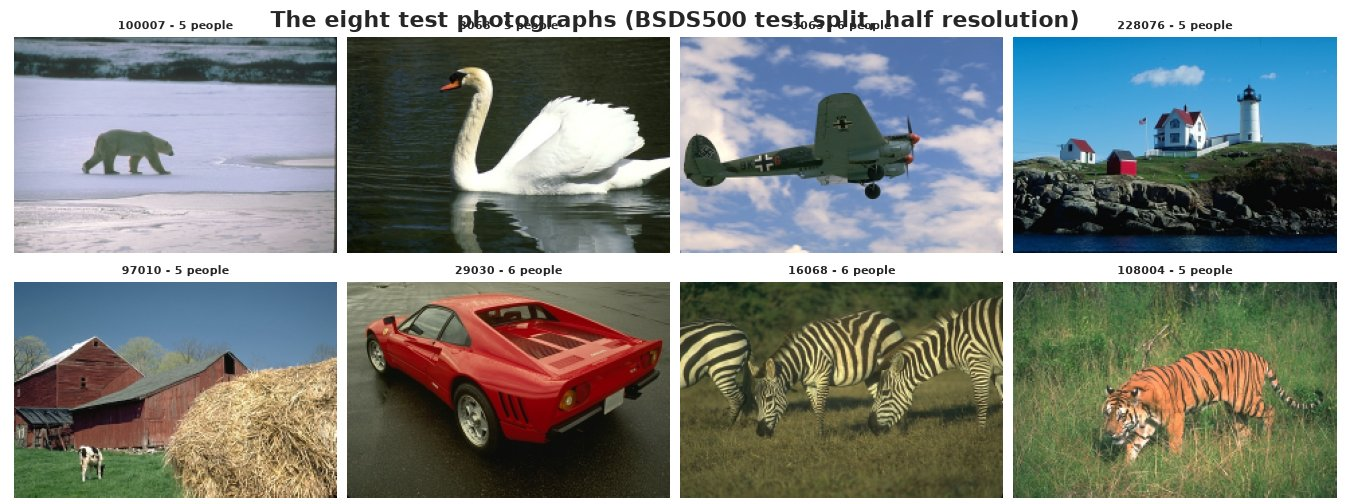

In [3]:
M_SRGB = np.array([[0.4124, 0.3576, 0.1805], [0.2126, 0.7152, 0.0722], [0.0193, 0.1192, 0.9505]])
D65_WHITE_2DEG = np.array([0.95047, 1.0, 1.08883])


def xyz_to_lab(XYZ):
    d = 6 / 29
    f = np.where(XYZ > d**3, np.cbrt(np.maximum(XYZ, 1e-12)), XYZ / (3 * d**2) + 4 / 29)
    return np.stack([116 * f[..., 1] - 16, 500 * (f[..., 0] - f[..., 1]), 200 * (f[..., 1] - f[..., 2])], -1)


def srgb_to_lab(rgb):
    lin = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)
    return xyz_to_lab(lin @ M_SRGB.T / D65_WHITE_2DEG)


def lab_to_srgb(lab):
    d = 6 / 29
    fy = (lab[..., 0] + 16) / 116
    f = np.stack([fy + lab[..., 1] / 500, fy, fy - lab[..., 2] / 200], -1)
    XYZ = np.where(f > d, f**3, 3 * d**2 * (f - 4 / 29)) * D65_WHITE_2DEG
    lin = np.clip(XYZ @ np.linalg.inv(M_SRGB).T, 0, 1)
    return np.where(lin <= 0.0031308, 12.92 * lin, 1.055 * lin ** (1 / 2.4) - 0.055)


def mean_colour_paint(img, lbl):
    """Paint every region of a label map in its mean colour (averaged in CIELAB)."""
    lab = srgb_to_lab(img)
    lbl = np.unique(lbl, return_inverse=True)[1].reshape(lbl.shape)
    cnt = np.bincount(lbl.ravel())
    mean = np.stack([np.bincount(lbl.ravel(), lab[..., k].ravel()) / cnt for k in range(3)], 1)
    return lab_to_srgb(mean[lbl])


def label_boundary(lbl):
    """Boundary pixels of a label map: the right or lower neighbour has another label."""
    b = np.zeros(lbl.shape, bool)
    b[:, :-1] |= lbl[:, :-1] != lbl[:, 1:]
    b[:-1, :] |= lbl[:-1, :] != lbl[1:, :]
    return b


def thick(m):
    """Thicken 1-pixel boundary maps for display only."""
    return ndimage.grey_dilation(m, size=(2, 2))


R_TOL = 2.0     # matching tolerance in pixels at half resolution (BSDS: 0.0075 x diagonal = 2.2)


def near(bmap, r=R_TOL):
    """Pixels within distance r of a boundary pixel."""
    if not bmap.any():
        return np.zeros(bmap.shape, bool)
    return ndimage.distance_transform_edt(~bmap) <= r


def human_maps(i):
    hb = [label_boundary(human[i, a]) for a in range(n_human[i])]
    freq = np.mean([near(b) for b in hb], 0)       # fraction of people with a boundary within R_TOL
    return hb, freq


SHOW = int(np.where(ids == "228076")[0][0])       # the photograph we study in detail
fig, axs = plt.subplots(2, 4, figsize=(15, 5.6), layout="none")
fig.subplots_adjust(wspace=0.03, hspace=0.12, left=0.01, right=0.99, top=0.93, bottom=0.01)
for ax, i in zip(axs.ravel(), TEST):
    ax.imshow(images[i])
    ax.set_title(f"{ids[i]} - {n_human[i]} people", fontsize=9)
    ax.axis("off")
fig.suptitle("The eight test photographs (BSDS500 test split, half resolution)")
show_jpeg(fig)

We study photograph 228076 (a lighthouse) in detail throughout, then all eight in Part G.

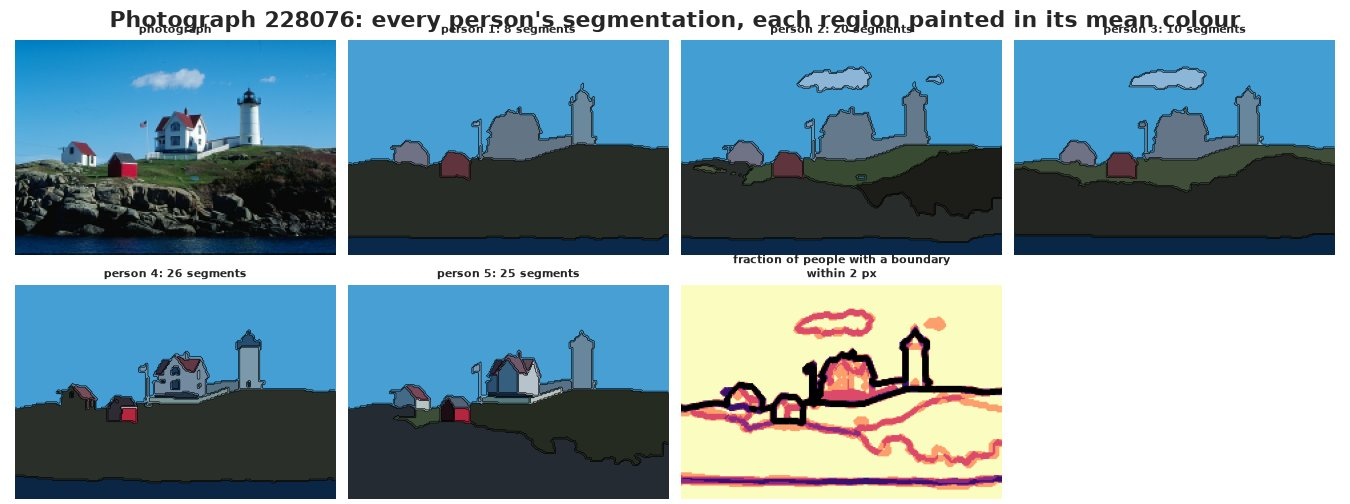

In [4]:
hb_show, hfreq_show = human_maps(SHOW)
na = n_human[SHOW]
fig, axs = plt.subplots(2, 4, figsize=(15, 5.6), layout="none")
fig.subplots_adjust(wspace=0.03, hspace=0.14, left=0.01, right=0.99, top=0.92, bottom=0.01)
axs[0, 0].imshow(images[SHOW])
axs[0, 0].set_title("photograph", fontsize=9)
for a in range(na):
    ax = axs.ravel()[a + 1]
    ax.imshow(mean_colour_paint(images[SHOW], human[SHOW, a]))
    ax.contour(label_boundary(human[SHOW, a]), levels=[0.5], colors="k", linewidths=0.5)
    ax.set_title(f"person {a + 1}: {len(np.unique(human[SHOW, a]))} segments", fontsize=9)
ax = axs.ravel()[na + 1]
ax.imshow(hfreq_show, cmap="magma_r", vmin=0, vmax=1)
ax.set_title("fraction of people with a boundary\nwithin 2 px", fontsize=9)
for ax in axs.ravel():
    ax.axis("off")
fig.suptitle(f"Photograph {ids[SHOW]}: every person's segmentation, each region painted in its mean colour")
show_jpeg(fig)

The five people agree about the outline of the buildings and the waterline (black), and differ about
the rest: two outline the cloud, the other three do not; some separate the grass from the rocks and
some do not; two outline windows and roof sides. (Person 1's 8 segments and person 4's 26 are both
"correct".)

**How well do people agree with each other?** The BSDS way to score a boundary map against people is
**precision** (the share of its boundary pixels that lie within tolerance of some person's boundary)
and **recall** (the share of each person's boundary pixels that lie within tolerance of it, averaged
over people), combined in the **F-measure** $F = 2PR/(P + R)$. We implement a simple version: a pixel
counts as matched if a boundary pixel of the other map lies within 2 pixels. The official benchmark
also insists on a one-to-one matching of pixels, which is stricter, so our numbers are somewhat
higher than published ones and are only comparable with each other. Scoring each person against the
others gives a **human reference**:

In [5]:
def f_measure(p, r):
    return 2 * p * r / max(p + r, 1e-12)


def pr_point(model_b, hb, r=R_TOL):
    """Tolerance-matched precision and recall of a boundary map against a list of human maps.
    precision: share of model boundary pixels within r of ANY person's boundary;
    recall: per person, share of their boundary pixels within r of the model's, averaged."""
    if model_b.sum() == 0:
        return 1.0, 0.0
    union = np.zeros(model_b.shape, bool)
    for h in hb:
        union |= near(h, r)
    prec = (model_b & union).sum() / model_b.sum()
    mn = near(model_b, r)
    rec = np.mean([(h & mn).sum() / max(h.sum(), 1) for h in hb])
    return prec, rec


def human_vs_rest(i):
    hb, _ = human_maps(i)
    out = []
    for a in range(len(hb)):
        p, r = pr_point(hb[a], [hb[b] for b in range(len(hb)) if b != a])
        out.append((p, r, f_measure(p, r)))
    return np.array(out)


hvr = human_vs_rest(SHOW)
print(pd.DataFrame(hvr, columns=["precision", "recall", "F"], index=[f"person {a + 1}" for a in range(na)]).round(2))

          precision  recall     F
person 1       0.99    0.64  0.78
person 2       0.90    0.82  0.86
person 3       0.94    0.78  0.85
person 4       0.92    0.71  0.80
person 5       0.94    0.66  0.77


People reach F = 0.77-0.86 against each other on this photograph. Their precision is high (0.90-0.99:
what one person draws, somebody else drew too) and their recall lower (0.64-0.82: nobody draws
everything that somebody else drew). A model should be judged against this spread, not against 1.

## B. Superpixels: what the model will see

Clustering 39,000 pixels one by one is slow and noisy: single pixels carry JPEG noise and texture.
We first group pixels into about 600 **superpixels** with **SLIC** (Achanta et al. 2012), which is
k-means in (row, column, L\*, a\*, b\*) with each centre searching only a small window: compact,
roughly equal-sized regions that follow colour edges. The whole algorithm is below (Numba for the
inner loop, and a flood fill that merges stray fragments into a neighbour).

Each superpixel becomes one observation with four **features**: its mean colour in CIELAB (L\*,
a\*, b\*: a space in which distance roughly matches perceived difference; conversion as in E74) and
a **texture** feature, the standard deviation of lightness *inside* it (a striped zebra and a flat
lawn can have the same mean colour but not the same texture). Neighbouring superpixels are connected
in a graph, each edge weighted by the length of the shared boundary. Every boundary the model can
draw is a superpixel boundary.

In [6]:
@nb.njit
def _slic_assign(lab, centres, S, m, labels, dist):
    H, W, _ = lab.shape
    dist[:] = np.inf
    for c in range(centres.shape[0]):
        cy, cx = centres[c, 0], centres[c, 1]
        y0, y1 = max(0, int(cy - 2 * S)), min(H, int(cy + 2 * S) + 1)
        x0, x1 = max(0, int(cx - 2 * S)), min(W, int(cx + 2 * S) + 1)
        for y in range(y0, y1):
            for x in range(x0, x1):
                dc = 0.0
                for k in range(3):
                    dc += (lab[y, x, k] - centres[c, 2 + k]) ** 2
                d = dc + ((y - cy) ** 2 + (x - cx) ** 2) / S**2 * m**2
                if d < dist[y, x]:
                    dist[y, x] = d
                    labels[y, x] = c


@nb.njit
def _enforce_connectivity(labels, min_size):
    """Relabel 4-connected pieces; pieces smaller than min_size join a neighbouring piece."""
    H, W = labels.shape
    out = -np.ones((H, W), np.int64)
    qy, qx = np.empty(H * W, np.int64), np.empty(H * W, np.int64)
    dy, dx = np.array([-1, 1, 0, 0]), np.array([0, 0, -1, 1])
    new = 0
    for y0 in range(H):
        for x0 in range(W):
            if out[y0, x0] >= 0:
                continue
            adj = -1
            for k in range(4):
                yy, xx = y0 + dy[k], x0 + dx[k]
                if 0 <= yy < H and 0 <= xx < W and out[yy, xx] >= 0:
                    adj = out[yy, xx]
            lab = labels[y0, x0]
            out[y0, x0] = new
            qy[0], qx[0] = y0, x0
            head, tail = 0, 1
            while head < tail:
                y, x = qy[head], qx[head]
                head += 1
                for k in range(4):
                    yy, xx = y + dy[k], x + dx[k]
                    if 0 <= yy < H and 0 <= xx < W and out[yy, xx] < 0 and labels[yy, xx] == lab:
                        out[yy, xx] = new
                        qy[tail], qx[tail] = yy, xx
                        tail += 1
            if tail < min_size and adj >= 0:
                for t in range(tail):
                    out[qy[t], qx[t]] = adj
            else:
                new += 1
    return out


def slic(lab, S=8, m=10.0, n_iter=10):
    """SLIC superpixels (Achanta et al. 2012): k-means in (y, x, L, a, b), searched locally."""
    H, W, _ = lab.shape
    cy, cx = np.meshgrid(np.arange(S / 2, H, S), np.arange(S / 2, W, S), indexing="ij")
    cy, cx = cy.ravel(), cx.ravel()
    centres = np.column_stack([cy, cx, lab[cy.astype(int), cx.astype(int)]])
    labels, dist = np.zeros((H, W), np.int64), np.zeros((H, W))
    Y, X = np.mgrid[:H, :W]
    for _ in range(n_iter):
        _slic_assign(lab, centres, S, m, labels, dist)
        cnt = np.bincount(labels.ravel(), minlength=len(centres)).astype(float)
        ok = cnt > 0
        for j, v in enumerate([Y, X, lab[..., 0], lab[..., 1], lab[..., 2]]):
            centres[ok, j] = np.bincount(labels.ravel(), v.ravel(), minlength=len(centres))[ok] / cnt[ok]
    return _enforce_connectivity(labels, S * S // 4)


FEATS = ["L*", "a*", "b*", "texture (sd of L*)"]


def superpixels(img, S=8):
    """Superpixel map, features (mean L*a*b* and the sd of L* inside), pixel counts, and the
    adjacency graph with shared boundary lengths."""
    lab = srgb_to_lab(img)
    sp = slic(lab, S=S)
    cnt = np.bincount(sp.ravel())
    means = [np.bincount(sp.ravel(), lab[..., k].ravel()) / cnt for k in range(3)]
    sd = np.sqrt(np.maximum(np.bincount(sp.ravel(), (lab[..., 0] ** 2).ravel()) / cnt - means[0] ** 2, 0))
    a = np.concatenate([sp[:, :-1].ravel(), sp[:-1, :].ravel()])
    b = np.concatenate([sp[:, 1:].ravel(), sp[1:, :].ravel()])
    keep = a != b
    n = sp.max() + 1
    key, blen = np.unique(np.minimum(a[keep], b[keep]) * n + np.maximum(a[keep], b[keep]), return_counts=True)
    return dict(sp=sp, X=np.column_stack(means + [sd]), npix=cnt, edges=np.column_stack([key // n, key % n]),
                blen=blen)


t0 = time.time()
G = {i: superpixels(images[i]) for i in range(len(ids))}
print(f"superpixels for {len(ids)} photographs in {time.time() - t0:.1f} s; "
      f"{min(len(g['X']) for g in G.values())}-{max(len(g['X']) for g in G.values())} superpixels each, "
      f"{np.median([g['npix'].mean() for g in G.values()]):.0f} pixels on average")
g = G[SHOW]
print(f"photograph {ids[SHOW]}: {len(g['X'])} superpixels, {len(g['edges'])} neighbouring pairs")

superpixels for 10 photographs in 0.8 s; 548-606 superpixels each, 66 pixels on average
photograph 228076: 583 superpixels, 1585 neighbouring pairs


Ten photographs are cut into 548-606 superpixels of 66 pixels on average in about a second.

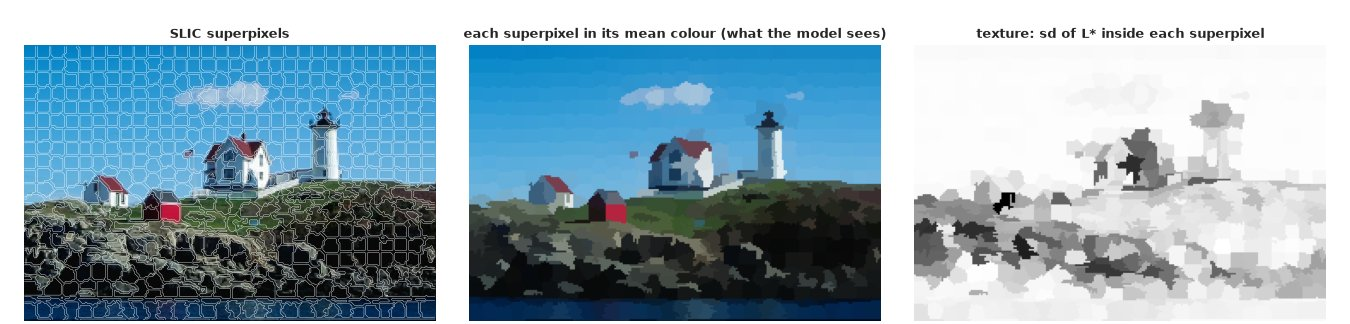

all superpixel boundaries against the people: precision 0.32, recall 0.98


In [7]:
def edge_map(g, p_edge):
    """Pixel map of an edge quantity: the value on the superpixel boundary at that pixel, 0 inside."""
    sp = g["sp"]
    n = sp.max() + 1
    E = np.zeros((n, n))
    E[g["edges"][:, 0], g["edges"][:, 1]] = p_edge
    E[g["edges"][:, 1], g["edges"][:, 0]] = p_edge
    out = np.zeros(sp.shape)
    out[:, :-1] = np.maximum(out[:, :-1], E[sp[:, :-1], sp[:, 1:]])
    out[:-1, :] = np.maximum(out[:-1, :], E[sp[:-1, :], sp[1:, :]])
    return out


fig, axs = plt.subplots(1, 3, figsize=(15, 3.6), layout="none")
fig.subplots_adjust(wspace=0.03, left=0.01, right=0.99, top=0.86, bottom=0.01)
axs[0].imshow(images[SHOW])
axs[0].contour(label_boundary(g["sp"]), levels=[0.5], colors="w", linewidths=0.3)
axs[0].set_title("SLIC superpixels", fontsize=10)
axs[1].imshow(lab_to_srgb(g["X"][:, :3])[g["sp"]])
axs[1].set_title("each superpixel in its mean colour (what the model sees)", fontsize=10)
axs[2].imshow(g["X"][:, 3][g["sp"]], cmap="Greys")
axs[2].set_title("texture: sd of L* inside each superpixel", fontsize=10)
for ax in axs:
    ax.axis("off")
show_jpeg(fig)

p_all, r_all = pr_point(label_boundary(g["sp"]), hb_show)
print(f"all superpixel boundaries against the people: precision {p_all:.2f}, recall {r_all:.2f}")

The mosaic in the middle is the whole of what the model gets: 583 colours and textures, and who
borders whom. It keeps the lighthouse, the houses, the red shed and the cloud; small details
(windows, the flagpole) are at or below its resolution. The texture map separates the rough rocks
(dark) from the flat sky and water (white). Superpixels cost almost nothing in recall: all
superpixel boundaries together come within 2 pixels of 98% of what people drew (with precision
0.32, since most superpixel boundaries are not segment boundaries). The model's job is to decide
which of the 1,585 neighbouring pairs are.

## C. A plain mixture in PyMC

The first model ignores where the superpixels are. Each superpixel's standardised feature vector
$x_i$ comes from one of $K$ Gaussian clusters with diagonal covariance, and the number of clusters is
left open by a **truncated stick-breaking** (Dirichlet-process) prior on the weights:

$$w = \text{StickBreaking}(\alpha), \quad \alpha \sim \text{Gamma}(2, 2), \quad
x_i \sim \sum_{k=1}^{12} w_k\, \mathcal N(\mu_k, \text{diag}\,\sigma_k^2).$$

With 12 components and a small $\alpha$ most weights should be tiny, and the number of components
with real weight is the posterior's estimate of K. The cluster labels are summed out (the mixture
likelihood), so NUTS samples only continuous parameters. (`pm.StickBreakingWeights(alpha, K)` returns
K + 1 weights, hence `K=KT - 1`.) A segment here is a **colour class**: all superpixels in one
cluster, connected or not.

In [8]:
Xs = (g["X"] - g["X"].mean(0)) / g["X"].std(0)
KT = 12
with pm.Model(coords={"component": range(KT), "feature": FEATS}) as plain:
    alpha_ = pm.Gamma("alpha", 2.0, 2.0)
    w_ = pm.StickBreakingWeights("w", alpha=alpha_, K=KT - 1, dims="component")
    mu_ = pm.Normal("mu", 0.0, 1.5, dims=("component", "feature"))
    sigma_ = pm.HalfNormal("sigma", 1.0, dims=("component", "feature"))
    comp = pm.logp(pm.Normal.dist(mu_[None], sigma_[None]), Xs[:, None, :]).sum(-1)
    pm.Potential("loglik", pt.logsumexp(pt.log(w_)[None, :] + comp, axis=1).sum())
    t0 = time.time()
    idata_plain = pm.sample(tune=1000, random_seed=RANDOM_SEED, progressbar=False)
print(f"sampled in {time.time() - t0:.0f} s; divergences: {int(idata_plain.sample_stats['diverging'].sum())}")
print("largest r_hat of the component means:", float(az.rhat(idata_plain, var_names=["mu"])["mu"].max()))
print("mean log posterior density per chain:", idata_plain.sample_stats["logp"].mean("draw").values.round(0))

sampled in 8 s; divergences: 0
largest r_hat of the component means: 2.8421334429518055
mean log posterior density per chain: [-593. -488. -654. -583.]


The warning signs are all there: the largest r_hat of a component mean is 2.8, and the chains
settle at mean log densities between -654 and -488, more than 150 apart. Part of the r_hat is
**label switching** (component 3 in one chain is component 8 in another), which is harmless. The
difference in log density is not: the chains are in **different modes**, different ways of carving
the colours into clusters.

Label-invariant quantities are the way to look at a mixture. For each draw, the **responsibility**
$r_{ik} = P(z_i = k \mid \text{parameters})$ gives the probability that superpixels $i$ and $j$ share a
cluster, $\sum_k r_{ik} r_{jk}$, which does not care what the clusters are called. Averaged over
draws, one minus that for neighbours is the posterior **probability of a boundary** between them.
Compare it chain by chain:

In [9]:
def responsibilities(post_w, post_mu, post_sigma, X):
    """P(superpixel i in component k | parameters) for each draw: (draws, n, K)."""
    logr = np.log(post_w)[:, None, :] + stats.norm.logpdf(X[None, :, None, :], post_mu[:, None], post_sigma[:, None]).sum(-1)
    r = np.exp(logr - logr.max(-1, keepdims=True))
    return r / r.sum(-1, keepdims=True)


chain_edge = []
for c in range(4):
    pc = idata_plain.posterior.isel(chain=c, draw=slice(None, None, 5))
    r = responsibilities(pc["w"].values, pc["mu"].values, pc["sigma"].values, Xs)
    same = np.einsum("sik,sik->si", r[:, g["edges"][:, 0]], r[:, g["edges"][:, 1]])
    chain_edge.append(1 - same.mean(0))
chain_edge = np.array(chain_edge)
occupied = (idata_plain.posterior["w"] > 0.01).sum("component")
print("components with more than 1% weight, per chain:", occupied.median("draw").values)
print(f"P(boundary) on neighbouring superpixels, largest disagreement between chains: "
      f"{(chain_edge.max(0) - chain_edge.min(0)).max():.2f}; mean {(chain_edge.max(0) - chain_edge.min(0)).mean():.2f}")
print(f"share of neighbouring pairs with P(boundary) > 0.2 (pooled): {(chain_edge.mean(0) > 0.2).mean():.2f}")

components with more than 1% weight, per chain: [12. 12. 12. 12.]
P(boundary) on neighbouring superpixels, largest disagreement between chains: 1.00; mean 0.16
share of neighbouring pairs with P(boundary) > 0.2 (pooled): 0.52


Three problems at once:

* **The truncation binds.** All 12 components carry more than 1% of the weight in every chain: the
  data want more clusters than we allowed, so "K" is just the truncation level. (Diagonal Gaussians
  are a poor shape for colour classes: a sky that darkens towards the top is an elongated cloud of
  points, which the mixture covers with several round ones.)
* **The chains disagree** about where the boundaries are: by up to 1.00 in probability on some
  neighbouring pairs, 0.16 on average.
* **Nothing makes a segment hang together.** Half of all neighbouring pairs (52%) have a boundary
  probability above 0.2.

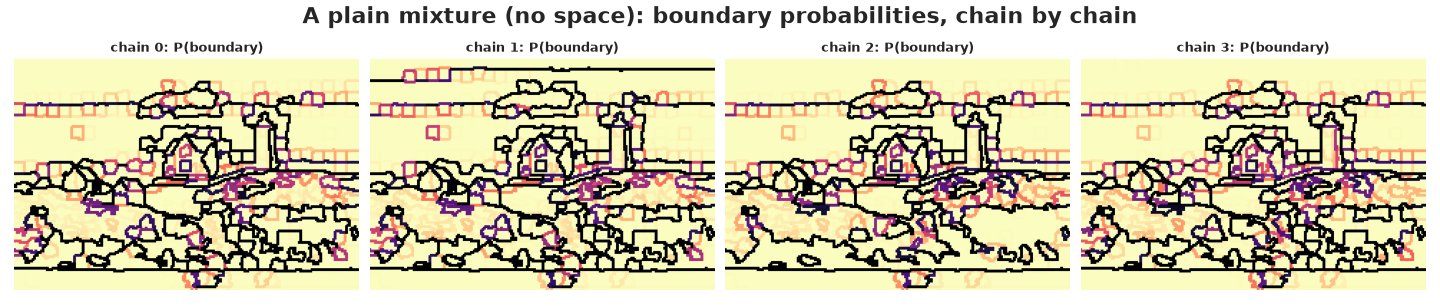

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(16, 3.4), layout="none")
fig.subplots_adjust(wspace=0.03, left=0.01, right=0.99, top=0.85, bottom=0.01)
for c, ax in enumerate(axs):
    ax.imshow(thick(edge_map(g, chain_edge[c])), cmap="magma_r", vmin=0, vmax=1)
    ax.set_title(f"chain {c}: P(boundary)", fontsize=10)
    ax.axis("off")
fig.suptitle("A plain mixture (no space): boundary probabilities, chain by chain")
show_jpeg(fig)

The maps show what "no space" means: the sky is sliced into horizontal bands (its gradient crosses
several clusters), isolated superpixels in the sky and the grass get boxes of their own, and the
rocks are a maze. A person would not draw most of these lines. Each chain draws a somewhat different
maze.

## D. Adding space: a Potts prior on the partition, and a sampler we can trust

### The model

Write the segmentation as a partition $z$ of the superpixels ($z_i$ = the segment of superpixel $i$,
labels arbitrary). The prior on partitions combines a **Chinese restaurant process** (the partition
implied by a Dirichlet process, concentration $\alpha$), which leaves the number of segments open,
with a **Potts** term that rewards neighbours for sharing a segment:

$$p(z) \propto \underbrace{\alpha^{K}\prod_{k=1}^{K}(n_k - 1)!}_{\text{CRP}}\;
\exp\Big(\beta \sum_{i \sim j} w_{ij}\, \mathbf 1[z_i = z_j]\Big),$$

where $n_k$ is the size of segment $k$, $i \sim j$ runs over neighbouring superpixels and $w_{ij}$ is
their shared boundary length divided by the average one. This is the MRF-constrained Dirichlet
process of Orbanz & Buhmann (2008). Each segment's features are Gaussian with an unknown mean and a
full covariance, with a **Normal-inverse-Wishart** prior (mean at the image's average feature,
$\kappa_0 = 0.05$, $\nu_0 = D + 2$, prior scale $s = 8$ units per feature: the typical spread of
superpixels inside one segment). Conjugacy lets us **integrate the cluster parameters out**: the
marginal likelihood of the superpixels in a segment, $m(x_{\text{segment}})$, has a closed form, and
the posterior is a distribution over partitions only,

$$p(z \mid x) \propto p(z) \prod_{k} m\big(\{x_i : z_i = k\}\big).$$

$\alpha = 1$ is fixed and $\beta$ is fixed per run and chosen on the training photographs below. They
are fixed because the Potts normalising constant (a sum over all partitions) depends on both, so
updating them inside the sampler is not a simple Gibbs step (exchange or pseudo-likelihood methods
exist; see "Try it yourself").

### The sampler

Three moves, all exact for this posterior:

1. **Collapsed Gibbs, one superpixel at a time** (Neal 2000's algorithm 3 plus the Potts term):
   superpixel $i$ joins existing segment $k$ with probability proportional to
   $n_{k}\, e^{\beta \sum_{j \sim i} w_{ij} \mathbf 1[z_j = k]}\, m(x_i \mid \text{segment } k)$,
   or a new segment with probability proportional to $\alpha\, m(x_i)$.
2. **Swendsen-Wang block moves** (Swendsen & Wang 1987; Edwards & Sokal 1988). Single-site moves
   cannot move a whole region: every superpixel inside it is held by its neighbours. So bond each
   pair of neighbours in the same segment with probability $1 - e^{-\beta w_{ij}}$; given the bonds,
   the Potts factor is a constant, and each bonded block can be moved to any segment (or a new one)
   by an exact Gibbs step that uses only the CRP and the marginal likelihoods.
3. **Parallel tempering** (Geyer 1991): four copies of the chain run at inverse temperatures
   $\tau = 1, 0.9, 0.8, 0.7$ (the posterior raised to the power $\tau$), and neighbouring copies
   propose to swap states after every sweep. The flatter copies cross between modes more easily and
   pass what they find down to $\tau = 1$, the only copy we keep.

In addition, $\beta$ is **annealed**: it rises from 0 to its value over the first quarter of the run
(burn-in only, discarded). The next cells check this machinery before we trust it.

In [11]:
@nb.njit
def _logdet_chol(A):
    """log det of a small SPD matrix by an in-place Cholesky (A is overwritten)."""
    D = A.shape[0]
    ld = 0.0
    for j in range(D):
        s = A[j, j]
        for k in range(j):
            s -= A[j, k] ** 2
        A[j, j] = math.sqrt(s)
        ld += 2 * math.log(A[j, j])
        for i in range(j + 1, D):
            s = A[i, j]
            for k in range(j):
                s -= A[i, k] * A[j, k]
            A[i, j] = s / A[j, j]
    return ld


def niw(m0, k0, nu0, Psi0, nmax):
    """A Normal-inverse-Wishart prior as a tuple, with the terms of the log marginal likelihood
    that depend only on the cluster size n tabulated for n = 0..nmax."""
    D = len(m0)
    n = np.arange(nmax + 1)
    gtab = (-n * D / 2 * np.log(np.pi) + nu0 / 2 * np.linalg.slogdet(Psi0)[1] + D / 2 * (np.log(k0) - np.log(k0 + n))
            + sum(gammaln((nu0 + n) / 2 - j / 2) - gammaln(nu0 / 2 - j / 2) for j in range(D)))
    return (np.asarray(m0, float), float(k0), float(nu0), np.asarray(Psi0, float), gtab)


@nb.njit
def log_ml(n, sx, sxx, pr):
    """log marginal likelihood of n feature vectors (sum sx, sum of outer products sxx) under a
    Normal-inverse-Wishart prior pr: the cluster's mean and covariance integrated out."""
    m0, k0, nu0, Psi0, gtab = pr
    D = m0.shape[0]
    if n == 0:
        return 0.0
    kn, nun = k0 + n, nu0 + n
    A = np.empty((D, D))
    for i in range(D):
        mi = (k0 * m0[i] + sx[i]) / kn
        for j in range(i + 1):
            mj = (k0 * m0[j] + sx[j]) / kn
            A[i, j] = Psi0[i, j] + sxx[i, j] + k0 * m0[i] * m0[j] - kn * mi * mj
    return gtab[n] - nun / 2 * _logdet_chol(A)


@nb.njit
def log_ml_plus(n, sx, sxx, ax, axx, pr):
    """log_ml(n, sx + ax, sxx + axx) without building the sums (the sampler's inner loop)."""
    m0, k0, nu0, Psi0, gtab = pr
    D = m0.shape[0]
    kn, nun = k0 + n, nu0 + n
    A = np.empty((D, D))
    for i in range(D):
        mi = (k0 * m0[i] + sx[i] + ax[i]) / kn
        for j in range(i + 1):
            mj = (k0 * m0[j] + sx[j] + ax[j]) / kn
            A[i, j] = Psi0[i, j] + sxx[i, j] + axx[i, j] + k0 * m0[i] * m0[j] - kn * mi * mj
    return gtab[n] - nun / 2 * _logdet_chol(A)


@nb.njit
def _sample_log(lp, K):
    mx = -np.inf
    for k in range(K):
        mx = max(mx, lp[k])
    tot = 0.0
    for k in range(K):
        lp[k] = math.exp(lp[k] - mx)
        tot += lp[k]
    u = np.random.random() * tot
    c = 0.0
    for k in range(K):
        c += lp[k]
        if u <= c:
            return k
    return K - 1


@nb.njit
def _find(par, i):
    while par[i] != i:
        par[i] = par[par[i]]
        i = par[i]
    return i


@nb.njit
def _drop_if_empty(k_old, K, z, cnt, sx, sxx, lml):
    """If cluster k_old is empty, move the last cluster into its slot (labels stay 0..K-1)."""
    if cnt[k_old] > 0:
        return K
    last = K - 1
    if k_old != last:
        cnt[k_old], lml[k_old] = cnt[last], lml[last]
        sx[k_old], sxx[k_old] = sx[last], sxx[last]
        for j in range(z.shape[0]):
            if z[j] == last:
                z[j] = k_old
    cnt[last], lml[last] = 0, 0.0
    sx[last], sxx[last] = 0.0, 0.0
    return K - 1


@nb.njit
def _sweep(X, xx, lml1, ptr, nbr, w, z, cnt, sx, sxx, lml, K, alpha, beta, tau, lw,
           pr, lp, lmlnew, pot, par, comp_n, members, start, fill):
    """One single-site Gibbs sweep, then one Swendsen-Wang block step, for the posterior raised
    to the power tau (tempering) with the likelihood weighted by lw (lw = 0: the prior)."""
    n, D = X.shape
    for i in np.random.permutation(n):
        k_old = z[i]
        cnt[k_old] -= 1
        sx[k_old] -= X[i]
        sxx[k_old] -= xx[i]
        lml[k_old] = log_ml(cnt[k_old], sx[k_old], sxx[k_old], pr)
        K = _drop_if_empty(k_old, K, z, cnt, sx, sxx, lml)
        pot[:K] = 0.0
        for e in range(ptr[i], ptr[i + 1]):
            pot[z[nbr[e]]] += w[e]
        for k in range(K):
            lmlnew[k] = log_ml_plus(cnt[k] + 1, sx[k], sxx[k], X[i], xx[i], pr)
            lp[k] = tau * (math.log(cnt[k]) + lw * (lmlnew[k] - lml[k]) + beta * pot[k])
        lp[K] = tau * (math.log(alpha) + lw * lml1[i])
        k_new = _sample_log(lp, K + 1)
        if k_new == K:
            K += 1
            lml[k_new] = lml1[i]
        else:
            lml[k_new] = lmlnew[k_new]
        z[i] = k_new
        cnt[k_new] += 1
        sx[k_new] += X[i]
        sxx[k_new] += xx[i]
    if beta <= 0:
        return K
    # Swendsen-Wang: bond equal-label neighbours with probability 1 - exp(-tau beta w) ...
    for i in range(n):
        par[i] = i
    for i in range(n):
        for e in range(ptr[i], ptr[i + 1]):
            j = nbr[e]
            if j > i and z[j] == z[i] and np.random.random() < 1 - math.exp(-tau * beta * w[e]):
                ri, rj = _find(par, i), _find(par, j)
                if ri != rj:
                    par[ri] = rj
    comp_n[:] = 0
    for i in range(n):
        comp_n[_find(par, i)] += 1
    start[0] = 0
    for r in range(n):
        start[r + 1] = start[r] + comp_n[r]
        fill[r] = start[r]
    for i in range(n):
        r = _find(par, i)
        members[fill[r]] = i
        fill[r] += 1
    # ... then Gibbs-update the label of each bonded block: given the bonds, the Potts factor is
    # constant, so only the partition prior and the marginal likelihoods matter
    cx_, cxx_ = np.zeros(D), np.zeros((D, D))
    for r in np.random.permutation(n):
        m = comp_n[r]
        if m < 2:
            continue
        cx_[:] = 0.0
        cxx_[:] = 0.0
        for t in range(start[r], start[r + 1]):
            cx_ += X[members[t]]
            cxx_ += xx[members[t]]
        k_old = z[members[start[r]]]
        cnt[k_old] -= m
        sx[k_old] -= cx_
        sxx[k_old] -= cxx_
        lml[k_old] = log_ml(cnt[k_old], sx[k_old], sxx[k_old], pr)
        K = _drop_if_empty(k_old, K, z, cnt, sx, sxx, lml)
        for k in range(K):
            lmlnew[k] = log_ml_plus(cnt[k] + m, sx[k], sxx[k], cx_, cxx_, pr)
            lp[k] = tau * (math.lgamma(cnt[k] + m) - math.lgamma(cnt[k]) + lw * (lmlnew[k] - lml[k]))
        lml_c = log_ml(m, cx_, cxx_, pr)
        lp[K] = tau * (math.log(alpha) + math.lgamma(m) + lw * lml_c)
        k_new = _sample_log(lp, K + 1)
        if k_new == K:
            K += 1
            lml[k_new] = lml_c
        else:
            lml[k_new] = lmlnew[k_new]
        for t in range(start[r], start[r + 1]):
            z[members[t]] = k_new
        cnt[k_new] += m
        sx[k_new] += cx_
        sxx[k_new] += cxx_
    return K


@nb.njit
def _log_post(z, cnt, lml, K, n, ptr, nbr, w, alpha, beta, lw):
    """Unnormalised log posterior of a partition: CRP x Potts x marginal likelihoods."""
    lp = math.lgamma(alpha) - math.lgamma(alpha + n)
    for k in range(K):
        lp += math.log(alpha) + math.lgamma(cnt[k]) + lw * lml[k]
    s = 0.0
    for i in range(n):
        for e in range(ptr[i], ptr[i + 1]):
            if z[nbr[e]] == z[i]:
                s += w[e]
    return lp + beta * s / 2


@nb.njit
def _swap(arr, r):
    tmp = arr[r].copy()
    arr[r] = arr[r + 1]
    arr[r + 1] = tmp


@nb.njit
def potts_dp(X, ptr, nbr, w, z0, alpha, beta, pr, taus, n_iter, thin, seed,
             n_anneal=0, lw=1.0):
    """Collapsed Gibbs + Swendsen-Wang for a CRP(alpha) x Potts(beta) partition prior with
    NIW-Gaussian clusters, with parallel tempering over inverse temperatures `taus` (taus[0] = 1).
    beta ramps up from 0 over the first n_anneal iterations. Returns the tau = 1 partitions (every
    thin-th iteration), their log posterior, and the swap acceptance rate of each adjacent pair."""
    np.random.seed(seed)
    n, D = X.shape
    R, kmax = taus.shape[0], n + 2
    Z = np.empty((R, n), np.int64)
    cnt = np.zeros((R, kmax), np.int64)
    sx, sxx = np.zeros((R, kmax, D)), np.zeros((R, kmax, D, D))
    lml, Ks = np.zeros((R, kmax)), np.zeros(R, np.int64)
    xx, lml1 = np.empty((n, D, D)), np.empty(n)
    for i in range(n):
        xx[i] = np.outer(X[i], X[i])
        lml1[i] = log_ml(1, X[i], xx[i], pr)
    mp = -np.ones(z0.max() + 1, np.int64)
    K0 = 0
    for i in range(n):
        if mp[z0[i]] < 0:
            mp[z0[i]] = K0
            K0 += 1
    for r in range(R):
        for i in range(n):
            k = mp[z0[i]]
            Z[r, i] = k
            cnt[r, k] += 1
            sx[r, k] += X[i]
            sxx[r, k] += xx[i]
        for k in range(K0):
            lml[r, k] = log_ml(cnt[r, k], sx[r, k], sxx[r, k], pr)
        Ks[r] = K0
    lp, lmlnew, pot = np.empty(kmax + 1), np.empty(kmax), np.zeros(kmax)
    par, comp_n, members = np.empty(n, np.int64), np.zeros(n, np.int64), np.empty(n, np.int64)
    start, fill, E = np.empty(n + 1, np.int64), np.empty(n, np.int64), np.empty(R)
    n_save = n_iter // thin
    out, out_lp = np.empty((n_save, n), np.int16), np.empty(n_save)
    acc, tries = np.zeros(max(R - 1, 1)), np.zeros(max(R - 1, 1))
    save = 0
    for it in range(n_iter):
        b = beta * min(1.0, (it + 1) / n_anneal) if n_anneal > 0 else beta
        for r in range(R):
            Ks[r] = _sweep(X, xx, lml1, ptr, nbr, w, Z[r], cnt[r], sx[r], sxx[r], lml[r], Ks[r], alpha, b,
                           taus[r], lw, pr, lp, lmlnew, pot, par, comp_n, members, start, fill)
        if R > 1:
            for r in range(R):
                E[r] = _log_post(Z[r], cnt[r], lml[r], Ks[r], n, ptr, nbr, w, alpha, b, lw)
            for r in range(it % 2, R - 1, 2):          # propose swaps between neighbouring temperatures
                tries[r] += 1
                if math.log(np.random.random()) < (taus[r] - taus[r + 1]) * (E[r + 1] - E[r]):
                    acc[r] += 1
                    _swap(Z, r)
                    _swap(cnt, r)
                    _swap(sx, r)
                    _swap(sxx, r)
                    _swap(lml, r)
                    Ks[r], Ks[r + 1] = Ks[r + 1], Ks[r]
        if (it + 1) % thin == 0:
            out[save] = Z[0]
            out_lp[save] = _log_post(Z[0], cnt[0], lml[0], Ks[0], n, ptr, nbr, w, alpha, b, lw)
            save += 1
    return out, out_lp, acc / np.maximum(tries, 1)


def csr(n, edges, w):
    """Neighbour lists of an undirected weighted graph (compressed sparse rows)."""
    src = np.concatenate([edges[:, 0], edges[:, 1]])
    dst = np.concatenate([edges[:, 1], edges[:, 0]])
    ww = np.concatenate([w, w]).astype(float)
    order = np.argsort(src, kind="stable")
    ptr = np.concatenate([[0], np.cumsum(np.bincount(src, minlength=n))])
    return ptr, dst[order].astype(np.int64), ww[order]


def log_post(z, X, edges, w, alpha, beta, prior, lw=1.0):
    """NumPy version of the log posterior (for enumeration and checks)."""
    n, D = X.shape
    z = np.unique(z, return_inverse=True)[1]
    lp = math.lgamma(alpha) - math.lgamma(alpha + n)
    for k in range(z.max() + 1):
        Xk = X[z == k]
        lp += math.log(alpha) + math.lgamma(len(Xk)) + lw * log_ml(len(Xk), Xk.sum(0), Xk.T @ Xk, prior)
    return lp + beta * (w * (z[edges[:, 0]] == z[edges[:, 1]])).sum()

### Check 1: exact enumeration on a tiny graph

Seven nodes have 877 partitions, few enough to compute the exact posterior of every one. On a small
graph with two groups of 2-D data, we compare the sampler's frequencies with the exact probabilities
by total-variation distance. Zero is not the target: even 100,000 independent exact draws would be
off by Monte Carlo error, so the last column shows what such draws give.

In [12]:
def partitions(n):
    def rec(i, z, K):
        if i == n:
            yield z.copy()
            return
        for k in range(K + 1):
            z[i] = k
            yield from rec(i + 1, z, max(K, k + 1))
    yield from rec(0, np.zeros(n, np.int64), 0)


def canon(z):
    seen = {}
    return tuple(seen.setdefault(v, len(seen)) for v in z)


rng_t = np.random.default_rng(1)
Xt = np.concatenate([rng_t.normal(0, 1, (3, 2)), rng_t.normal(2.5, 1, (4, 2))])
edges_t = np.array([[i, i + 1] for i in range(6)] + [[0, 3], [2, 5]])
w_t = rng_t.uniform(0.5, 1.5, len(edges_t))
prior_t = niw(np.zeros(2), 0.1, 4.0, np.eye(2), 7)
ptr_t, nbr_t, ww_t = csr(7, edges_t, w_t)
parts = list(partitions(7))
index = {canon(z): j for j, z in enumerate(parts)}
rows = []
for beta_t in [0.0, 1.5]:
    lp_exact = np.array([log_post(z, Xt, edges_t, w_t, 1.0, beta_t, prior_t) for z in parts])
    p_exact = np.exp(lp_exact - lp_exact.max())
    p_exact /= p_exact.sum()
    for label, taus in [("Gibbs + SW", np.array([1.0])), ("Gibbs + SW, tempered", np.array([1.0, 0.6, 0.3]))]:
        Zt, _, _ = potts_dp(Xt, ptr_t, nbr_t, ww_t, np.zeros(7, np.int64), 1.0, beta_t, prior_t, taus, 100_000, 1, 3)
        freq = np.bincount([index[canon(z)] for z in Zt], minlength=len(parts)) / len(Zt)
        iid = rng_t.multinomial(len(Zt), p_exact) / len(Zt)     # what exact independent draws would give
        rows.append((beta_t, label, 0.5 * np.abs(freq - p_exact).sum(), 0.5 * np.abs(iid - p_exact).sum()))
print(f"{len(parts)} partitions of 7 nodes")
print(pd.DataFrame(rows, columns=["beta", "sampler", "TV(sampler, exact)", "TV(100k exact draws, exact)"]).round(4)
      .to_string(index=False))

877 partitions of 7 nodes
 beta              sampler  TV(sampler, exact)  TV(100k exact draws, exact)
  0.0           Gibbs + SW              0.0093                       0.0081
  0.0 Gibbs + SW, tempered              0.0091                       0.0078
  1.5           Gibbs + SW              0.0056                       0.0029
  1.5 Gibbs + SW, tempered              0.0031                       0.0058


The sampler is off by about as much as exact independent draws would be (0.003-0.009, within a
factor of two of the last column), with and without tempering, and with the Potts term off
($\beta = 0$) and on ($\beta = 1.5$). The code does what the equations say.

### Check 2: a synthetic image with known segments

Now a photograph-sized test with a known answer: four regions (two of them similar reddish
colours), with blotchy colour noise at the scale of a superpixel plus pixel noise. We fit $\beta$ = 0
(no spatial prior), 1 and 2 and measure the distance of each posterior draw from the truth by the
**variation of information** (VI; Meila 2007), a distance between partitions that is 0 for identical
ones.

In [13]:
Yg, Xg = np.mgrid[:H, :W]
truth = np.zeros((H, W), int)
truth[Yg > 0.55 * H + 12 * np.sin(Xg / 25)] = 1
truth[(Yg - 60) ** 2 + (Xg - 70) ** 2 < 32**2] = 2
truth[(abs(Yg - 95) < 28) & (abs(Xg - 175) < 38)] = 3
lab_true = np.array([[66, 10, 8], [52, 26, 26], [48, -20, 25], [72, 0, -25]], float)
rng_s = np.random.default_rng(7)
blotches = np.stack([ndimage.gaussian_filter(rng_s.normal(0, 1, (H, W)), 4) for _ in range(3)], -1)
lab_syn = lab_true[truth] + 6 * blotches / blotches.std() + rng_s.normal(0, 6, (H, W, 3))
img_syn = np.clip(lab_to_srgb(lab_syn), 0, 1)
g_syn = superpixels(img_syn)
truth_sp = np.array([np.bincount(truth[g_syn["sp"] == s]).argmax() for s in range(len(g_syn["X"]))])


def niw_prior(X, s=8.0):
    D = X.shape[1]
    nu0 = D + 2.0
    return niw(X.mean(0), 0.05, nu0, (nu0 - D - 1) * s**2 * np.eye(D), len(X))


TAUS = np.array([1.0, 0.9, 0.8, 0.7])


def fit(g, beta, chains=2, n_iter=600, thin=3, burn=100, n_anneal=150, alpha=1.0, s=8.0, taus=TAUS, seed=0, z0=None):
    """Run chains of the tempered sampler; returns (chains, draws, n) partitions and log posteriors."""
    n = len(g["X"])
    ptr, nbr, w = csr(n, g["edges"], g["blen"] / g["blen"].mean())
    Zs, lps = [], []
    for c in range(chains):
        start = np.random.default_rng(seed + c).integers(0, 20, n) if z0 is None else z0
        Z, lp, acc = potts_dp(g["X"], ptr, nbr, w, start, alpha, beta, niw_prior(g["X"], s), taus, n_iter, thin,
                              seed + c, n_anneal)
        Zs.append(Z[burn:])
        lps.append(lp[burn:])
    return np.array(Zs), np.array(lps), acc


def edge_probs(Z, edges):
    Z = Z.reshape(-1, Z.shape[-1])
    return np.mean(Z[:, edges[:, 0]] != Z[:, edges[:, 1]], axis=0)


def n_clusters(Z):
    return np.array([len(np.unique(z)) for z in Z.reshape(-1, Z.shape[-1])])


@nb.njit
def vi_dist(a, b, wt):
    """Variation of information between two partitions, nodes weighted by wt (summing to 1)."""
    J = np.zeros((a.max() + 1, b.max() + 1))
    for i in range(a.shape[0]):
        J[a[i], b[i]] += wt[i]
    pa, pb = J.sum(1), J.sum(0)
    h = 0.0
    for k in range(pa.shape[0]):
        if pa[k] > 0:
            h += pa[k] * math.log(pa[k])
    for l in range(pb.shape[0]):
        if pb[l] > 0:
            h += pb[l] * math.log(pb[l])
    for k in range(J.shape[0]):
        for l in range(J.shape[1]):
            if J[k, l] > 0:
                h -= 2 * J[k, l] * math.log(J[k, l])
    return h


t0 = time.time()
syn = {}
for beta in [0.0, 1.0, 2.0]:
    Zc, lpc, _ = fit(g_syn, beta)
    Z = Zc.reshape(-1, Zc.shape[-1]).astype(np.int64)
    wt = g_syn["npix"] / g_syn["npix"].sum()
    syn[beta] = dict(Z=Z, K=n_clusters(Z), vi=np.array([vi_dist(z, truth_sp, wt) for z in Z]), pe=edge_probs(Z, g_syn["edges"]))
print(f"synthetic fits in {time.time() - t0:.0f} s")
print(pd.DataFrame({f"beta = {b:g}": {"K (median)": np.median(v["K"]), "K 90% interval": np.quantile(v["K"], [0.05, 0.95]),
                                      "VI to truth (median)": np.median(v["vi"]).round(3)} for b, v in syn.items()}))

synthetic fits in 10 s
                        beta = 0    beta = 1    beta = 2
K (median)                   5.0         5.0         5.0
K 90% interval        [5.0, 7.0]  [5.0, 5.0]  [4.0, 5.0]
VI to truth (median)       0.156       0.033       0.018


All three settings find the four regions, plus a fifth, thin class: superpixels on the edges of the
rectangle and the disc that straddle two colours (the "mixed" superpixels any superpixel method
makes). The spatial prior shows in the details. Without it ($\beta = 0$) the posterior median VI to
the truth is 0.16, and K reaches 7 in 5% of draws; with $\beta = 1$ it is 0.03 and with $\beta = 2$
0.02.

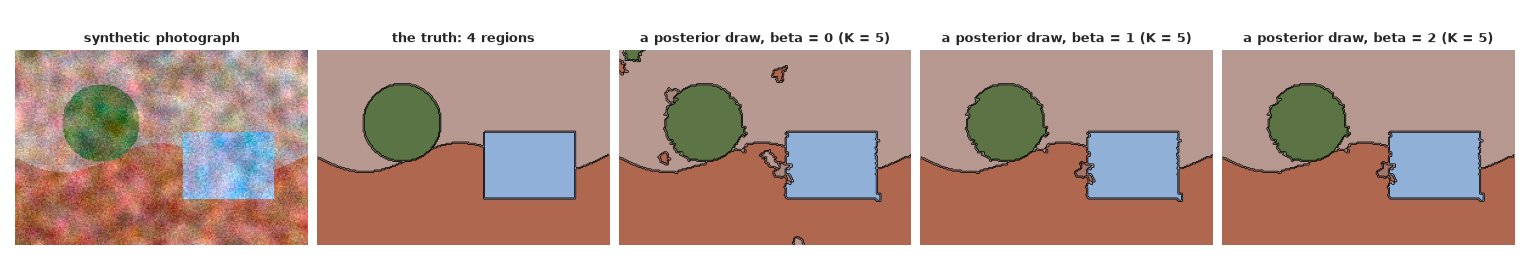

In [14]:
fig, axs = plt.subplots(1, 5, figsize=(17, 2.9), layout="none")
fig.subplots_adjust(wspace=0.03, left=0.01, right=0.99, top=0.86, bottom=0.01)
axs[0].imshow(img_syn)
axs[0].set_title("synthetic photograph", fontsize=10)
axs[1].imshow(mean_colour_paint(img_syn, truth))
axs[1].contour(label_boundary(truth), levels=[0.5], colors="k", linewidths=0.6)
axs[1].set_title("the truth: 4 regions", fontsize=10)
for ax, b in zip(axs[2:], [0.0, 1.0, 2.0]):
    z = syn[b]["Z"][-1]
    ax.imshow(mean_colour_paint(img_syn, z[g_syn["sp"]]))
    ax.contour(label_boundary(z[g_syn["sp"]]), levels=[0.5], colors="k", linewidths=0.6)
    ax.set_title(f"a posterior draw, beta = {b:g} (K = {len(np.unique(z))})", fontsize=10)
for ax in axs:
    ax.axis("off")
show_jpeg(fig)

Without the spatial prior, blotches that happen to look like the other reddish region become
islands of it, scattered through both halves: the speckle of Part C, now on an image where we know
it is wrong. With $\beta = 1$ or 2 the islands are gone and only the outlines are ragged at the scale of
a superpixel.

### What the prior believes, and a trap

**Prior predictive check.** Before fitting real photographs, what does the partition prior alone
say? Switch the likelihood off (the sampler has a weight `lw` for it) and draw partitions of the
lighthouse's superpixel graph for a range of $\beta$, from two different starting points.

prior draws in 5 s
 beta              start  K median  K 5%  K 95%  largest segment's share
 0.00        one segment       6.0  3.45   10.0                     0.72
 0.00 20 random segments       7.0  4.00   11.0                     0.69
 0.01        one segment       4.0  1.00    7.0                     0.98
 0.01 20 random segments       4.0  2.00    7.0                     0.97
 0.02        one segment       3.0  1.00    6.0                     0.99
 0.02 20 random segments       3.0  1.00    5.0                     0.99
 0.03        one segment       3.0  1.00    5.0                     0.99
 0.03 20 random segments       3.0  1.00    6.0                     0.99
 0.05        one segment       2.0  1.00    4.0                     1.00
 0.05 20 random segments       2.0  1.00    4.0                     1.00
 0.10        one segment       2.0  1.00    4.0                     1.00
 0.10 20 random segments       2.0  1.00    3.0                     1.00
 0.30        one segment       1

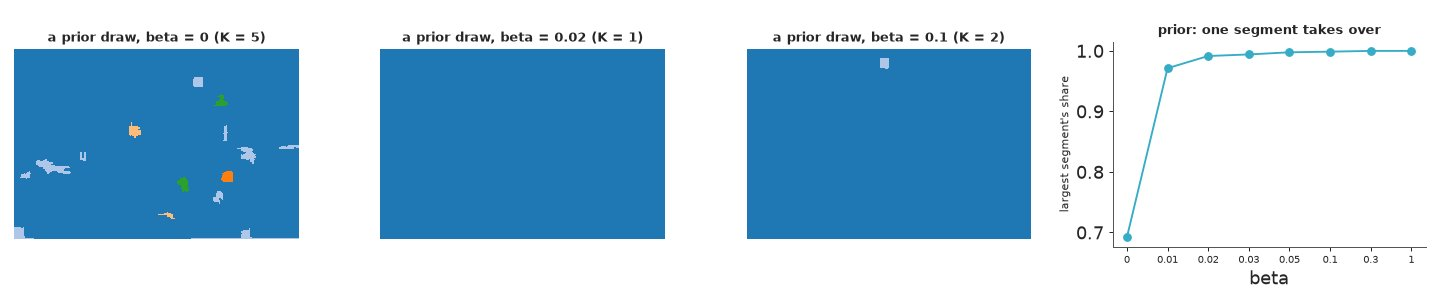

In [15]:
t0 = time.time()
prior_rows, prior_draws = [], {}
n_show = len(g["X"])
ptr_, nbr_, w_ = csr(n_show, g["edges"], g["blen"] / g["blen"].mean())
BETA_PRIOR = [0.0, 0.01, 0.02, 0.03, 0.05, 0.1, 0.3, 1.0]
for beta in BETA_PRIOR:
    for start_name, start in [("one segment", np.zeros(n_show, np.int64)),
                              ("20 random segments", np.random.default_rng(5).integers(0, 20, n_show))]:
        Zp, _, _ = potts_dp(g["X"], ptr_, nbr_, w_, start, 1.0, beta, niw_prior(g["X"]), TAUS[:1], 400, 2, 11, 0, 0.0)
        Zp = Zp[50:].astype(np.int64)      # lw = 0: the likelihood is switched off, so these are prior draws
        Kp = n_clusters(Zp)
        big = np.array([np.bincount(z, weights=g["npix"]).max() / g["npix"].sum() for z in Zp])
        prior_rows.append((beta, start_name, np.median(Kp), np.quantile(Kp, 0.05), np.quantile(Kp, 0.95), np.median(big)))
        prior_draws[beta] = Zp[-1]
print(f"prior draws in {time.time() - t0:.0f} s")
prior_tab = pd.DataFrame(prior_rows, columns=["beta", "start", "K median", "K 5%", "K 95%", "largest segment's share"])
print(prior_tab.round(2).to_string(index=False))

fig, axs = plt.subplots(1, 4, figsize=(16, 3.3), layout="none", gridspec_kw={"width_ratios": [1, 1, 1, 1.1]})
fig.subplots_adjust(wspace=0.28, left=0.01, right=0.99, top=0.86, bottom=0.17)
for ax, beta in zip(axs[:3], [0.0, 0.02, 0.1]):
    z = prior_draws[beta]
    ax.imshow(plt.cm.tab20(z[g["sp"]] % 20), interpolation="nearest")
    ax.set_title(f"a prior draw, beta = {beta:g} (K = {len(np.unique(z))})", fontsize=10)
    ax.axis("off")
pt_ = prior_tab[prior_tab.start == "20 random segments"]
axs[3].plot(range(len(pt_)), pt_["largest segment's share"], "-o", color="C0")
axs[3].set_xticks(range(len(pt_)), [f"{b:g}" for b in pt_.beta], fontsize=8)
axs[3].set_xlabel("beta")
axs[3].set_ylabel("largest segment's share", fontsize=9)
axs[3].set_title("prior: one segment takes over", fontsize=10)
show_jpeg(fig)

The prior on its own is nothing like a photograph's segmentation. Even without the Potts term
($\beta = 0$) the Chinese restaurant process with $\alpha = 1$ puts about 70% of the superpixels in one
segment and scatters the rest in crumbs (K = 6-7). The slightest spatial coupling then takes over:
at $\beta = 0.01$ the largest segment already covers 97% of the image, and from $\beta = 0.3$ on the
prior is essentially "one segment" (both starting points agree, so this is the prior, not the
sampler). Yet $\beta = 1$ and 2 gave clean, correct segmentations of the synthetic image. **$\beta$ has no
meaning on its own**: what matters is its strength relative to the likelihood, and each superpixel's
marginal likelihood is worth several nats. A prior predictive check of the partition prior alone
would have talked us out of every useful value.

In [16]:
t0 = time.time()
Z_one, lp_one, _ = fit(g, 2.0, chains=1, taus=TAUS[:1], n_anneal=0, z0=np.zeros(len(g["X"]), np.int64))
Z_ok, lp_ok, acc_ok = fit(g, 2.0, chains=1)
print(f"{time.time() - t0:.0f} s")
print(f"start in one segment, no tempering, no annealing: K = {np.median(n_clusters(Z_one)):.0f}, "
      f"log posterior {lp_one.mean():.0f}")
print(f"random start, beta annealed, 4 temperatures:      K = {np.median(n_clusters(Z_ok)):.0f}, "
      f"log posterior {lp_ok.mean():.0f}; swap rates {acc_ok.round(2)}")

3 s
start in one segment, no tempering, no annealing: K = 2, log posterior -5058
random start, beta annealed, 4 temperatures:      K = 6, log posterior -3799; swap rates [0.63 0.34 0.53]


**The trap.** The prior at large $\beta$ puts everything in one segment, and so does a *naive
sampler* started there. Started with every superpixel in one segment, with no tempering and no
annealing, a chain at $\beta = 2$ stays near that state: K = 2 and a log posterior of -5058. The
same model, started from 20 random segments with $\beta$ annealed and four temperatures, reaches
K = 6 and -3799: **1,259 nats higher**. The first chain is not describing a mode of the posterior; it
is stuck (a single superpixel that leaves pays the Potts penalty for all its neighbours, and at
$\beta = 2$ a pair of neighbours is bonded with probability $1 - e^{-2} = 0.86$, so the Swendsen-Wang
blocks are nearly the whole image). Nothing in the sampler complains: only comparing chains from
different starts, by their log posterior, reveals it. Every fit from here on starts at
random labels, anneals $\beta$ and tempers.

### Choosing $\beta$ on the training photographs

$\beta$ decides how much the model smooths, and neither the prior (which collapses) nor theory tells
us its value. We treat it as a **tuning constant chosen on held-out data**: for $\beta$ = 0, 1, 2 and 3,
fit the two *training* photographs and score the posterior boundary probabilities against their
people by the best F-measure over thresholds.

In [17]:
def boundary_scores(pe_map, hb, thresholds):
    return np.array([pr_point(pe_map >= t, hb) for t in thresholds])


TH = np.linspace(0.05, 0.95, 19)
t0 = time.time()
tune_rows = []
for beta in [0.0, 1.0, 2.0, 3.0]:
    for i in TRAIN:
        Zc, lpc, _ = fit(G[i], beta, chains=1, seed=100)
        pr = boundary_scores(edge_map(G[i], edge_probs(Zc, G[i]["edges"])), human_maps(i)[0], TH)
        f = [f_measure(p, r) for p, r in pr]
        tune_rows.append((beta, ids[i], max(f), np.median(n_clusters(Zc))))
tune = pd.DataFrame(tune_rows, columns=["beta", "photograph", "best F", "K"])
print(f"{time.time() - t0:.0f} s")
print(tune.pivot(index="beta", columns="photograph", values=["best F", "K"]).round(3))
BETA = float(tune.groupby("beta")["best F"].mean().idxmax())
print("chosen beta:", BETA)

20 s
           best F             K       
photograph 113044 118035 113044 118035
beta                                  
0.0         0.812  0.812    9.0   11.0
1.0         0.880  0.803    6.0    9.0
2.0         0.881  0.778    5.0    8.0
3.0         0.888  0.751    4.0    6.0
chosen beta: 1.0


$\beta = 1$ has the best average (0.84, against 0.81 without the spatial prior); larger values keep
helping the horses (113044) but hurt the church (118035), which has many small parts. Larger $\beta$
also means fewer segments (K from 9-11 at $\beta = 0$ down to 4-6 at $\beta = 3$). The differences
are modest: this is a sensitivity check as much as a choice. From here on $\beta = 1$.

## E. The posterior for one photograph

Four chains for the lighthouse, each with four tempered copies, 800 sweeps of which the first 200
anneal $\beta$ and the first 300 are discarded.

In [18]:
t0 = time.time()
Zc, lpc, acc = fit(g, BETA, chains=4, n_iter=800, n_anneal=200, burn=100, seed=RANDOM_SEED)
print(f"4 chains in {time.time() - t0:.0f} s; swap acceptance {acc.round(2)}")
Z = Zc.reshape(-1, Zc.shape[-1]).astype(np.int64)
lp_all = lpc.reshape(-1)
Kc = np.array([n_clusters(z) for z in Zc])
pe_chain = np.array([edge_probs(z, g["edges"]) for z in Zc])
print(pd.DataFrame({"mean log posterior": lpc.mean(1).round(1), "K median": np.median(Kc, 1),
                    "K 5%-95%": [tuple(np.quantile(k, [0.05, 0.95])) for k in Kc]}, index=[f"chain {c}" for c in range(4)]))
spread = pe_chain.max(0) - pe_chain.min(0)
print(f"P(boundary) per edge, spread between chains: max {spread.max():.2f}, 99th percentile "
      f"{np.quantile(spread, 0.99):.2f}, mean {spread.mean():.3f}")
lp_ds = xr.Dataset({"log_post": (("chain", "draw"), lpc), "K": (("chain", "draw"), Kc)})
print("r_hat:", {k: round(float(v), 3) for k, v in az.rhat(lp_ds).items()},
      " bulk ESS:", {k: round(float(v)) for k, v in az.ess(lp_ds).items()})

4 chains in 15 s; swap acceptance [0.64 0.49 0.42]
         mean log posterior  K median     K 5%-95%
chain 0             -5163.6       8.0  (8.0, 10.0)
chain 1             -5163.5       8.0  (8.0, 9.75)
chain 2             -5162.3       8.0   (8.0, 9.0)
chain 3             -5162.2       8.0   (8.0, 9.0)
P(boundary) per edge, spread between chains: max 0.21, 99th percentile 0.15, mean 0.014
r_hat: {'log_post': 1.006, 'K': 1.002}  bulk ESS: {'log_post': 451, 'K': 583}


The four chains agree: mean log posteriors within 1.4 nats, the same distribution of K, and boundary
probabilities that differ between chains by at most 0.21 on any neighbouring pair (0.014 on average).
r_hat on the two label-free scalars we can compute, the log posterior and K, is 1.006 and 1.002 with
bulk ESS over 450. Swaps between temperatures are accepted 42-64% of the time.

### The posterior probability of a boundary

The **co-assignment matrix** $P_{ij} = P(z_i = z_j \mid x)$, the share of posterior draws in which
superpixels $i$ and $j$ are in the same segment, summarises the partition posterior without labels.
For neighbours, $1 - P_{ij}$ is the posterior probability of a boundary between them, which we paint
on the pixels of their shared border.

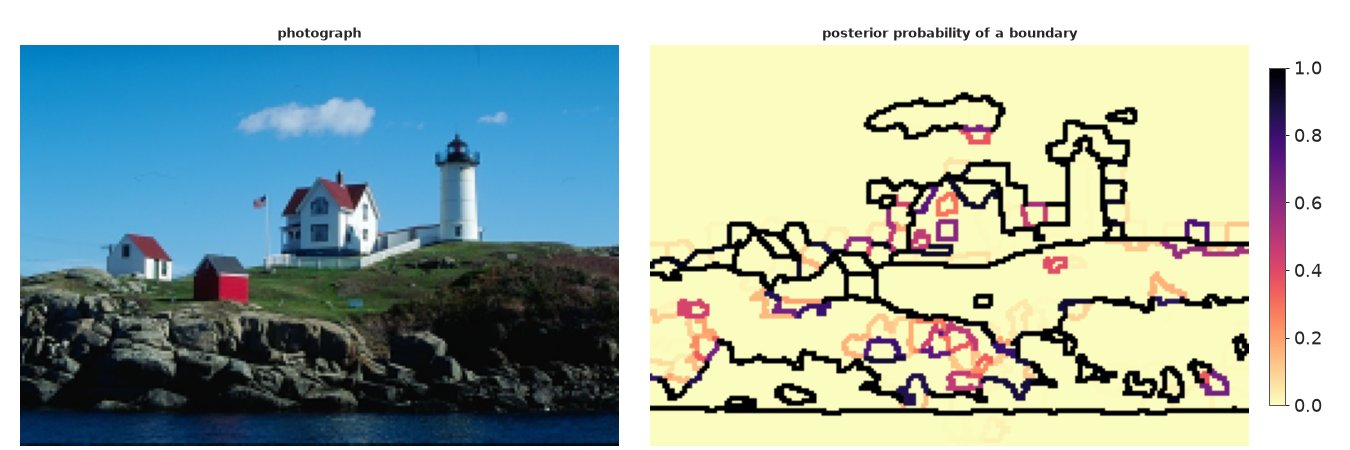

In [19]:
@nb.njit
def coassign(Z):
    S, n = Z.shape
    P = np.zeros((n, n))
    for s in range(S):
        for i in range(n):
            for j in range(i, n):
                if Z[s, i] == Z[s, j]:
                    P[i, j] += 1
    for i in range(n):
        for j in range(i, n):
            P[i, j] /= S
            P[j, i] = P[i, j]
    return P


P = coassign(Z)
pe = 1 - P[g["edges"][:, 0], g["edges"][:, 1]]
bprob = edge_map(g, pe)
fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout="none")
fig.subplots_adjust(wspace=0.03, left=0.01, right=0.93, top=0.9, bottom=0.01)
axs[0].imshow(images[SHOW])
axs[0].set_title("photograph", fontsize=10)
im = axs[1].imshow(thick(bprob), cmap="magma_r", vmin=0, vmax=1)
axs[1].set_title("posterior probability of a boundary", fontsize=10)
for ax in axs:
    ax.axis("off")
cax = fig.add_axes([0.94, 0.1, 0.012, 0.75])
fig.colorbar(im, cax=cax)
show_jpeg(fig)

Most boundaries are certain (black): the skyline, the houses, the cloud, the waterline, and a
surprising number of lines in the rocks and grass. The uncertain ones (orange and purple) are few
and short: parts of the rocks, the house's windows and roof edges, a patch at the edge of the cloud.
The posterior says "I know exactly where the segments are", and much of what it knows is about
colour: whether a person would draw those rock lines is another question (Part F).

### Click a pixel: which pixels share its segment?

A row of the co-assignment matrix is a map: for one seed pixel, the probability that every other
pixel is in the same segment. This is the most direct way to show a user what the model thinks
belongs together.

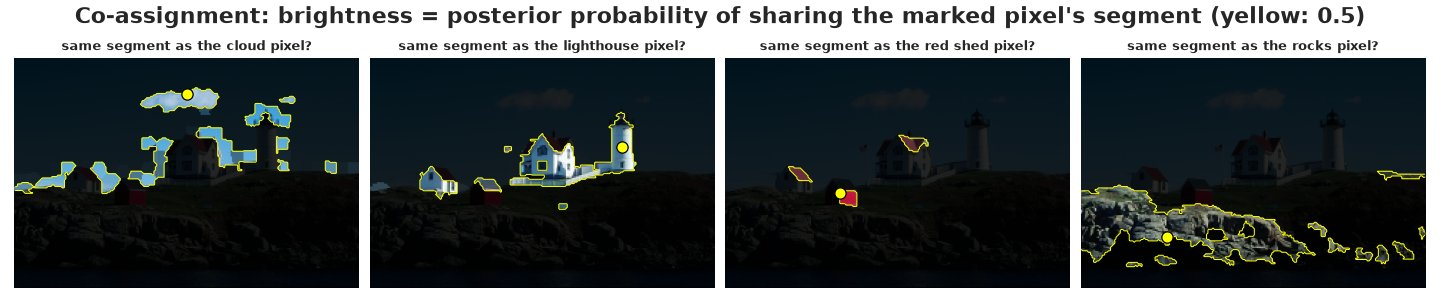

In [20]:
seeds = {"cloud": (25, 120), "lighthouse": (62, 176), "red shed": (94, 80), "rocks": (125, 60)}
fig, axs = plt.subplots(1, 4, figsize=(16, 3.4), layout="none")
fig.subplots_adjust(wspace=0.03, left=0.01, right=0.99, top=0.86, bottom=0.01)
for ax, (name, (y, x)) in zip(axs, seeds.items()):
    s = g["sp"][y, x]
    pmap = P[s][g["sp"]]
    ax.imshow(images[SHOW] * (0.15 + 0.85 * pmap[..., None]))
    ax.contour(pmap, levels=[0.5], colors="yellow", linewidths=0.8)
    ax.plot(x, y, marker="o", ms=9, mfc="yellow", mec="k")
    ax.set_title(f"same segment as the {name} pixel?", fontsize=10)
    ax.axis("off")
fig.suptitle("Co-assignment: brightness = posterior probability of sharing the marked pixel's segment (yellow: 0.5)")
show_jpeg(fig)

The cloud's segment is **pale sky**: the cloud, but also the paler blue sky around the buildings
and along the horizon on the left. This is the colour-class nature of the model: a segment is a set
of superpixels with the same colour statistics, and it does not have to be connected (a Potts prior
only makes it *locally* coherent). The lighthouse tower goes with the house walls and
the white house on the left; the red shed with the red roofs; the seed in the rocks with the light
grey rocks all along the shore. Brightness fades at the edges where the posterior is unsure.

### One segmentation to report: loss functions on partitions

Sometimes a single answer is needed. The posterior draw with the highest posterior density (the
"MAP", here the best partition visited) is one choice, but it is a single point in an enormous space
and not what minimises any expected error. Two losses between a reported partition $c$ and the truth
are standard (Binder 1978; Meila 2007; Wade & Ghahramani 2018):

* **Binder's loss** counts pairs of pixels on which $c$ and the truth disagree ("together" vs
  "apart"). Its expected value needs only the co-assignment matrix:
  $E[\text{Binder}(c)] = \sum_{i<j} w_i w_j\, \big|\mathbf 1[c_i = c_j] - P_{ij}\big|$, with $w_i$ the share
  of pixels in superpixel $i$ (so the loss counts pixel pairs, not superpixel pairs).
* The **variation of information**, $\text{VI}(c, z) = H(c) + H(z) - 2I(c, z)$, is an
  information-theoretic distance; its expected value is averaged over posterior draws.

We search over the partitions the sampler visited (Dahl 2006's approach; a greedy local search from
the best one can improve on it further).

In [21]:
@nb.njit
def binder_expected(C, P, wt):
    """Expected Binder loss (pixel-weighted, equal costs) of each candidate partition."""
    out = np.zeros(C.shape[0])
    n = C.shape[1]
    for c in range(C.shape[0]):
        tot = 0.0
        for i in range(n):
            for j in range(i + 1, n):
                same = 1.0 if C[c, i] == C[c, j] else 0.0
                tot += wt[i] * wt[j] * abs(same - P[i, j])
        out[c] = tot
    return out


@nb.njit
def vi_expected(C, Z, wt):
    out = np.zeros(C.shape[0])
    for c in range(C.shape[0]):
        for s in range(Z.shape[0]):
            out[c] += vi_dist(C[c], Z[s], wt)
        out[c] /= Z.shape[0]
    return out


wt = g["npix"] / g["npix"].sum()
cand_keys, cand_idx = np.unique(np.array([hash(canon(z)) for z in Z]), return_index=True)
C = Z[cand_idx]
Zthin = Z[::4]
t0 = time.time()
e_binder = binder_expected(C, P, wt)
e_vi = vi_expected(C, Zthin, wt)
print(f"{len(C)} distinct partitions among {len(Z)} draws; expected losses in {time.time() - t0:.1f} s")
point = {"MAP (best visited)": Z[lp_all.argmax()], "Binder": C[e_binder.argmin()], "VI": C[e_vi.argmin()]}
tab = []
for name, z in point.items():
    tab.append((name, len(np.unique(z)), binder_expected(z[None], P, wt)[0], vi_expected(z[None], Zthin, wt)[0]))
print(pd.DataFrame(tab, columns=["point estimate", "K", "expected Binder loss", "expected VI"]).round(4).to_string(index=False))

664 distinct partitions among 664 draws; expected losses in 0.8 s
    point estimate  K  expected Binder loss  expected VI
MAP (best visited)  8                0.0064       0.1824
            Binder  8                0.0060       0.1781
                VI  8                0.0060       0.1781


Every one of the 664 kept draws is a different partition (they differ in at least one superpixel),
yet all three point estimates have 8 segments, and the Binder and VI estimates are the same
partition. Its expected losses are slightly lower than the MAP's (Binder 0.0060 vs 0.0064; VI 0.178
vs 0.182), as they must be, since the MAP was among the candidates.

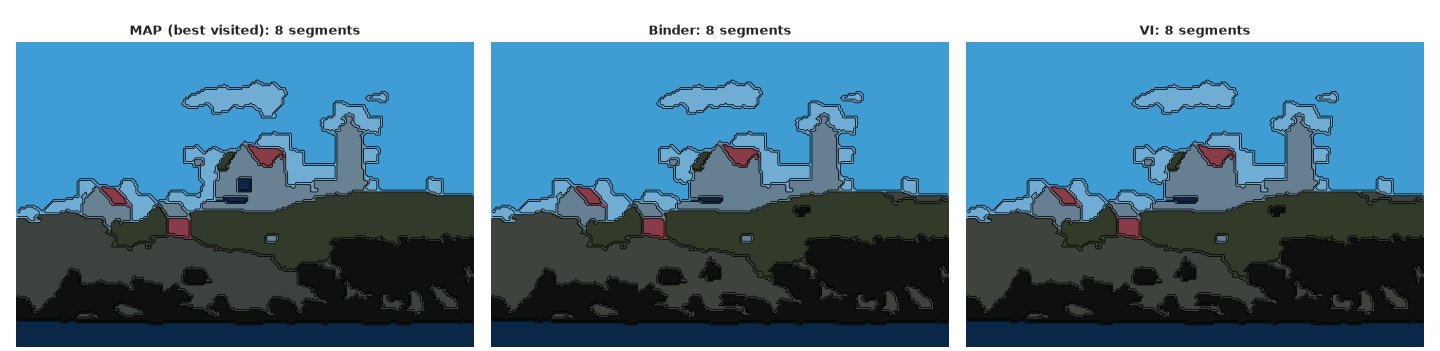

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(16, 3.9), layout="none")
fig.subplots_adjust(wspace=0.03, left=0.01, right=0.99, top=0.88, bottom=0.01)
for ax, (name, z) in zip(axs, point.items()):
    lbl = z[g["sp"]]
    ax.imshow(mean_colour_paint(images[SHOW], lbl))
    ax.contour(label_boundary(lbl), levels=[0.5], colors="k", linewidths=0.6)
    ax.set_title(f"{name}: {len(np.unique(z))} segments", fontsize=10)
    ax.axis("off")
show_jpeg(fig)

The three look almost the same; they differ only in a few superpixels around the main house's dark
windows. The posterior is concentrated enough that the choice of loss hardly matters for this
photograph.

### How many segments?

The posterior of K, next to each person's count, with a **representative** segmentation for each
value of K (among draws with that K, the one with the smallest expected VI to the posterior).

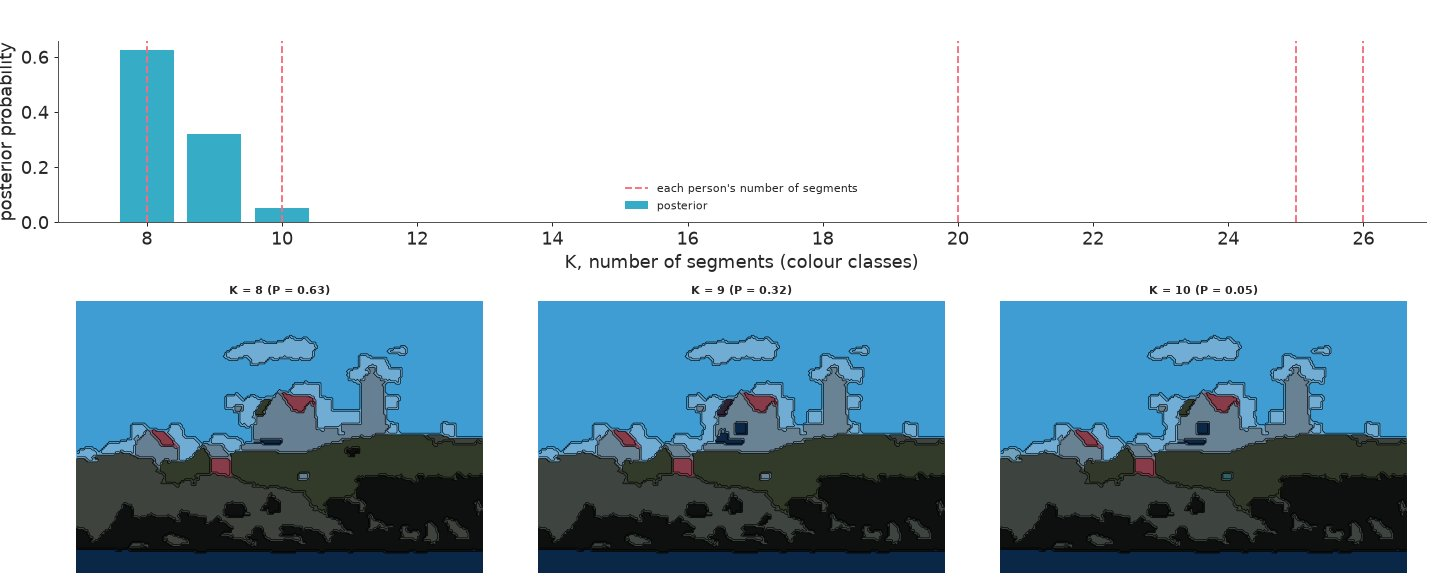

In [23]:
Kall = n_clusters(Z)
ks, kc = np.unique(Kall, return_counts=True)
keep = kc / kc.sum() >= 0.02
fig = plt.figure(figsize=(16, 6.5), layout="none")
gs = fig.add_gridspec(2, max(keep.sum(), 3), height_ratios=[1, 1.5], hspace=0.35, wspace=0.04,
                      left=0.04, right=0.99, top=0.93, bottom=0.02)
ax = fig.add_subplot(gs[0, :])
human_k = [len(np.unique(human[SHOW, a])) for a in range(na)]
ax.bar(ks, kc / kc.sum(), color="C0", width=0.8, label="posterior")
for hk in human_k:
    ax.axvline(hk, color="C1", lw=1.5, ls="--")
ax.plot([], [], color="C1", ls="--", label="each person's number of segments")
ax.set_xlabel("K, number of segments (colour classes)")
ax.set_xticks(range(min(ks.min(), min(human_k)), max(ks.max(), max(human_k)) + 1, 2))
ax.set_ylabel("posterior probability")
ax.legend(fontsize=9)
for j, k in enumerate(ks[keep]):
    sel = np.where(Kall == k)[0]
    rep = sel[np.argmin(vi_expected(Z[sel], Zthin, wt))]
    axk = fig.add_subplot(gs[1, j])
    lbl = Z[rep][g["sp"]]
    axk.imshow(mean_colour_paint(images[SHOW], lbl))
    axk.contour(label_boundary(lbl), levels=[0.5], colors="k", linewidths=0.5)
    axk.set_title(f"K = {k} (P = {kc[ks == k][0] / kc.sum():.2f})", fontsize=9)
    axk.axis("off")
show_jpeg(fig)

The posterior puts 0.63 on 8 segments, 0.32 on 9 and 0.05 on 10. The ninth and tenth segments are
small: dark windows on the main house and similar details. People used 8 to 26 segments. Two of the
five are inside the posterior's range; the other three drew far more detail (every window, roof side
and rock group) than colour statistics at this resolution can support. **The posterior of K is sharp,
and people are not**: the posterior answers "how many colour classes does this model need?", which is
not the question they were asked.

### Hypothetical outcomes

A grid of posterior draws shows the uncertainty the way a person would experience it: as several
plausible segmentations. Whatever stays the same in every panel is certain; whatever changes is not.
The animation cycles through 30 draws.

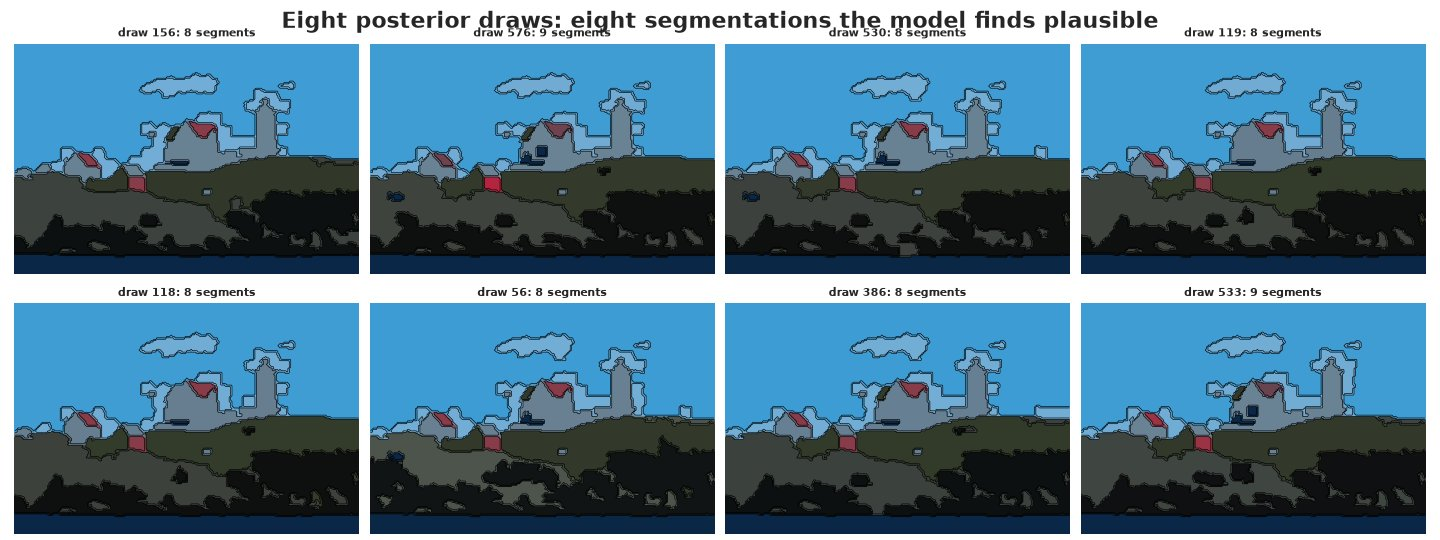

In [24]:
picks = np.random.default_rng(3).choice(len(Z), 8, replace=False)
fig, axs = plt.subplots(2, 4, figsize=(16, 6), layout="none")
fig.subplots_adjust(wspace=0.03, hspace=0.12, left=0.01, right=0.99, top=0.92, bottom=0.01)
for ax, d in zip(axs.ravel(), picks):
    lbl = Z[d][g["sp"]]
    ax.imshow(mean_colour_paint(images[SHOW], lbl))
    ax.contour(label_boundary(lbl), levels=[0.5], colors="k", linewidths=0.5)
    ax.set_title(f"draw {d}: {len(np.unique(Z[d]))} segments", fontsize=9)
    ax.axis("off")
fig.suptitle("Eight posterior draws: eight segmentations the model finds plausible")
show_jpeg(fig)

In [25]:
frames = np.random.default_rng(4).choice(len(Z), 30, replace=False)
fig, axs = plt.subplots(1, 2, figsize=(7.5, 2.8), dpi=72, layout="none")
fig.subplots_adjust(wspace=0.03, left=0.01, right=0.99, top=0.88, bottom=0.01)
axs[0].imshow(images[SHOW])
axs[0].set_title("photograph", fontsize=8)
frame = axs[1].imshow(mean_colour_paint(images[SHOW], Z[frames[0]][g["sp"]]))
for ax in axs:
    ax.axis("off")


def update(k):
    lbl = Z[frames[k]][g["sp"]]
    painted = mean_colour_paint(images[SHOW], lbl)
    painted[label_boundary(lbl)] = 0
    frame.set_data(painted)
    axs[1].set_title(f"posterior draw {frames[k]} ({len(np.unique(Z[frames[k]]))} segments)", fontsize=8)
    return (frame,)


anim = animation.FuncAnimation(fig, update, frames=range(len(frames)), interval=600)
plt.close(fig)
with plt.rc_context({"animation.frame_format": "jpeg"}):
    display(HTML(anim.to_jshtml(default_mode="loop")))

Across draws the skyline, buildings, cloud and waterline stay put. What changes is small: whether
the main house's windows and roof get a class of their own, where a few rock and grass superpixels
go, the pale sky at the right-hand horizon, a speck at the waterline. In the animation the picture
flickers only in those places.

## F. Checked against people

### Side by side

The same colour scale for both: the model's boundary probability, and the share of the five people
who drew a boundary at that pixel.

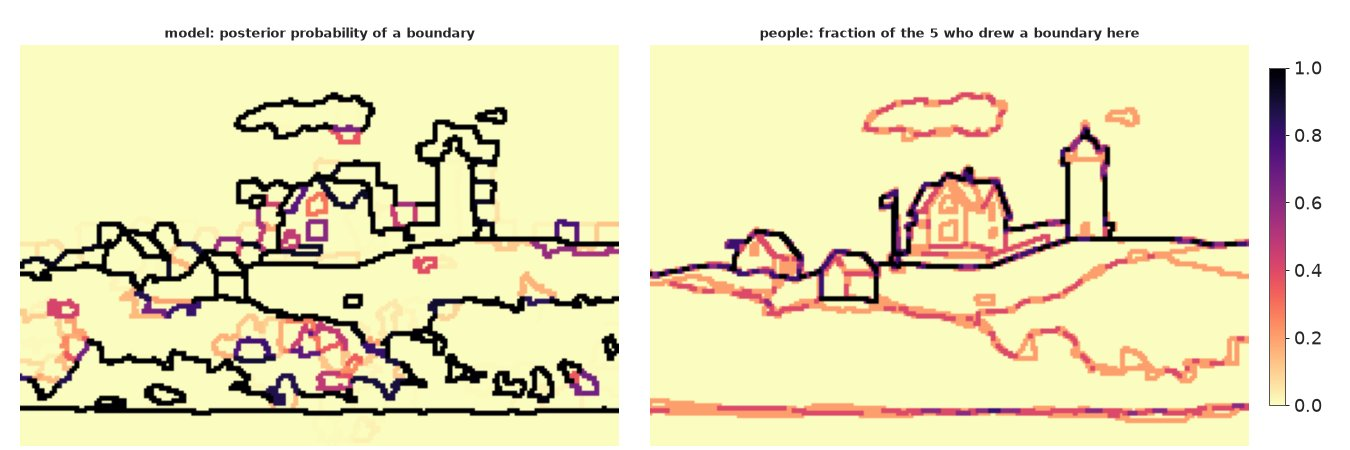

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout="none")
fig.subplots_adjust(wspace=0.03, left=0.01, right=0.93, top=0.9, bottom=0.01)
axs[0].imshow(thick(bprob), cmap="magma_r", vmin=0, vmax=1)
axs[0].set_title("model: posterior probability of a boundary", fontsize=10)
im = axs[1].imshow(thick(np.mean(hb_show, 0)), cmap="magma_r", vmin=0, vmax=1)
axs[1].set_title(f"people: fraction of the {na} who drew a boundary here", fontsize=10)
for ax in axs:
    ax.axis("off")
cax = fig.add_axes([0.94, 0.1, 0.012, 0.75])
fig.colorbar(im, cax=cax)
show_jpeg(fig)

Where people agree (the skyline, the houses, the lighthouse, the waterline) the model agrees too. The
disagreements are of two kinds. The model is **certain about boundaries few or no people drew**: the
maze of lines in the rocks and the grass, and the line between the pale and the deeper blue sky
around the buildings. And **people draw lines the model cannot**: the roofs, windows and walls of
the main house, the flagpole, the fence.

### Calibration

If the boundary probability were calibrated to people, then among pixels where the model says 0.3,
about 30% of people would have drawn a boundary within 2 pixels. We check that on the pixels where
the model can put a boundary (superpixel boundaries), in ten bins of the model's probability.

In [27]:
def calibration(bmap, hfreq, cand, bins=np.linspace(0, 1, 11)):
    """Among candidate boundary pixels, the mean human frequency in bins of model probability."""
    b, h = bmap[cand], hfreq[cand]
    j = np.clip(np.digitize(b, bins) - 1, 0, len(bins) - 2)
    return pd.DataFrame({"model": [b[j == k].mean() if (j == k).any() else np.nan for k in range(len(bins) - 1)],
                         "people": [h[j == k].mean() if (j == k).any() else np.nan for k in range(len(bins) - 1)],
                         "pixels": [(j == k).sum() for k in range(len(bins) - 1)]})


cand = label_boundary(g["sp"])
cal_show = calibration(bprob, hfreq_show, cand)
print(cal_show.round(2).to_string())

   model  people  pixels
0   0.00    0.09    7139
1   0.14    0.21     363
2   0.27    0.15      75
3   0.36    0.06      95
4   0.45    0.23     181
5   0.56    0.29      82
6   0.64    0.19      98
7   0.75    0.21      93
8   0.86    0.11     180
9   0.99    0.48    2188


It is not calibrated. Where the model is certain of a boundary (probability 0.99, 2,188 pixels) only
48% of people drew one; where it is certain there is none, 9% did. Almost all candidate pixels are in
those two bins: the model rarely says anything in between, and the few intermediate bins (each under
400 pixels) do not rise steadily. The posterior probability is a statement about this model at this
$\beta$, not a forecast of what people draw.

### Precision and recall

The standard benchmark display: precision against recall as the threshold on the boundary
probability moves, with the single partitions (MAP, Binder, VI) as points, each person against the
others as crosses, and a baseline: the **colour contrast** between neighbouring superpixels (distance
of their mean colours, scaled to 0-1), which has no model at all.

best F: posterior 0.74 (t = 0.90: precision 0.67, recall 0.81), colour contrast 0.72, people 0.81 on average


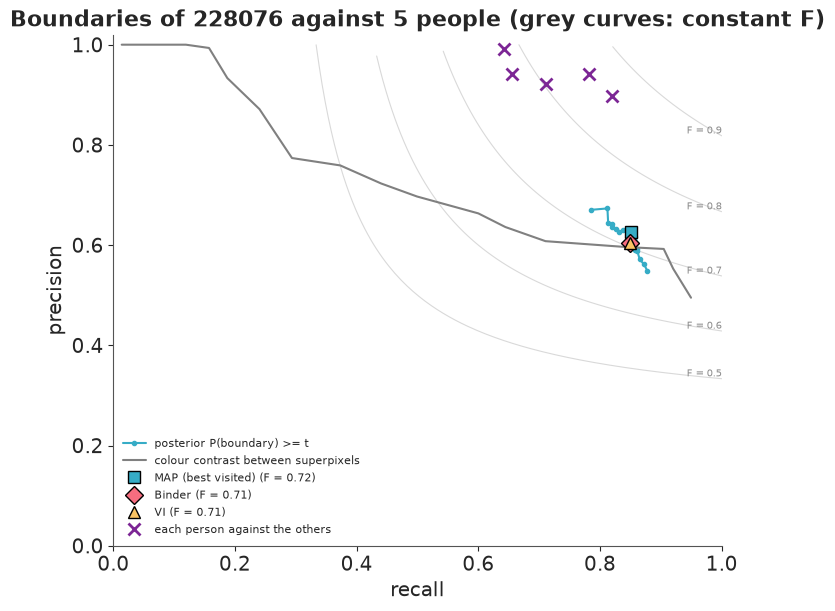

In [28]:
def contrast_map(g):
    d = np.linalg.norm(g["X"][g["edges"][:, 0], :3] - g["X"][g["edges"][:, 1], :3], axis=1)
    return edge_map(g, d / d.max())


pr_post = boundary_scores(bprob, hb_show, TH)
pr_con = boundary_scores(contrast_map(g), hb_show, TH)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(pr_post[:, 1], pr_post[:, 0], "-o", ms=3, color="C0", label="posterior P(boundary) >= t")
ax.plot(pr_con[:, 1], pr_con[:, 0], "-", color="0.5", label="colour contrast between superpixels")
for (name, z), mk in zip(point.items(), ["s", "D", "^"]):
    p, r = pr_point(label_boundary(z[g["sp"]]), hb_show)
    ax.plot(r, p, mk, ms=9, mec="k", label=f"{name} (F = {f_measure(p, r):.2f})")
ax.plot(hvr[:, 1], hvr[:, 0], "x", color="C3", ms=9, mew=2, label="each person against the others")
fgrid = np.linspace(0.01, 1, 200)
for fv in [0.5, 0.6, 0.7, 0.8, 0.9]:
    rr = fgrid[fgrid > fv / (2 - fv)]
    ax.plot(rr, fv * rr / (2 * rr - fv), color="0.85", lw=0.8, zorder=0)
    ax.text(1.0, fv / (2 - fv), f"F = {fv:g}", fontsize=7, color="0.55", ha="right", va="bottom")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.legend(fontsize=8, loc="lower left")
ax.set_title(f"Boundaries of {ids[SHOW]} against {na} people (grey curves: constant F)");
fp = [f_measure(p, r) for p, r in pr_post]
fc = [f_measure(p, r) for p, r in pr_con]
jb = int(np.argmax(fp))
print(f"best F: posterior {max(fp):.2f} (t = {TH[jb]:.2f}: precision {pr_post[jb, 0]:.2f}, recall {pr_post[jb, 1]:.2f}), "
      f"colour contrast {max(fc):.2f}, people {hvr[:, 2].mean():.2f} on average")

The posterior curve is short: its probabilities are nearly all 0 or 1, so moving the threshold barely
changes the boundary set. At its best it reaches F = 0.74 (threshold 0.9: precision 0.67, recall 0.81),
against 0.72 for colour contrast at its best threshold and 0.81 for people on average. The model
recalls about as much as people do; its weakness is **precision**, the lines nobody drew. The single
partitions sit on the curve (F = 0.71-0.72). Every person has higher precision than the model.

## G. Across photographs

The same analysis for all eight test photographs. To see how much of the disagreement with people is
about **granularity** (how finely to divide), each photograph is also fitted with a finer and a
coarser prior scale ($s$ = 4 and 16 instead of 8: a small $s$ says segments are homogeneous, so it
makes more of them). The **granularity ensemble** averages the three boundary-probability maps with
equal weight. This is not a posterior over $s$: given the data, the posterior of $s$ would be sharp
(the likelihood of 600 superpixels is decisive about it), and it would pick one granularity. People
do not. The ensemble is a deliberate statement that granularity is a choice the data cannot make,
the way people's instructions ("things of roughly equal importance") leave it open.

For $s = 8$ the lighthouse reuses the four chains of Part E; the other photographs get two chains
each, and $s$ = 4 and 16 one chain each.

In [29]:
SCALES = [4.0, 8.0, 16.0]
t0 = time.time()
res = {}
for i in TEST:
    if i == SHOW:
        Zi, lpi = Zc, lpc
    else:
        Zi, lpi, _ = fit(G[i], BETA, chains=2, seed=RANDOM_SEED)
    pe_i = np.array([edge_probs(z, G[i]["edges"]) for z in Zi])
    other = {s_: edge_probs(fit(G[i], BETA, chains=1, s=s_, seed=RANDOM_SEED + 10)[0], G[i]["edges"])
             for s_ in SCALES if s_ != 8.0}
    res[i] = dict(Z=Zi.reshape(-1, Zi.shape[-1]).astype(np.int64), lp=lpi, pe=pe_i.mean(0),
                  gap=np.ptp(lpi.mean(1)), spread=(pe_i.max(0) - pe_i.min(0)).max(),
                  pe_ens=np.mean([other[4.0], pe_i.mean(0), other[16.0]], 0))
print(f"{len(TEST)} photographs, 4 fits each, in {time.time() - t0:.0f} s")

8 photographs, 4 fits each, in 69 s


In [30]:
def best_f(pr):
    return max(f_measure(p, r) for p, r in pr)


rows, cal_all = [], []
for i in TEST:
    gi, r = G[i], res[i]
    hb_i, hf_i = human_maps(i)
    bmap, bens = edge_map(gi, r["pe"]), edge_map(gi, r["pe_ens"])
    zmap = r["Z"][r["lp"].reshape(-1).argmax()]
    Ki = n_clusters(r["Z"])
    rows.append({"photo": ids[i], "F: s = 8": best_f(boundary_scores(bmap, hb_i, TH)),
                 "F: MAP": f_measure(*pr_point(label_boundary(zmap[gi["sp"]]), hb_i)),
                 "F: ensemble": best_f(boundary_scores(bens, hb_i, TH)),
                 "F: contrast": best_f(boundary_scores(contrast_map(gi), hb_i, TH)),
                 "F: people": human_vs_rest(i)[:, 2].mean(),
                 "K (s = 8)": f"{np.median(Ki):.0f} [{np.quantile(Ki, 0.05):.0f}-{np.quantile(Ki, 0.95):.0f}]",
                 "people's segments": f"{min(len(np.unique(human[i, a])) for a in range(n_human[i]))}-"
                                      f"{max(len(np.unique(human[i, a])) for a in range(n_human[i]))}",
                 "chain gap (nats)": r["gap"], "edge spread": r["spread"]})
    cand_i = label_boundary(gi["sp"])
    cal_all.append(pd.DataFrame({"s = 8": bmap[cand_i], "ensemble": bens[cand_i], "h": hf_i[cand_i], "photo": ids[i]}))
summary = pd.DataFrame(rows)
print(summary.round(2).to_string(index=False))
print("\nmean F:", summary.filter(like="F:").mean().round(3).to_dict())

 photo  F: s = 8  F: MAP  F: ensemble  F: contrast  F: people K (s = 8) people's segments  chain gap (nats)  edge spread
100007      0.76    0.66         0.86         0.88       0.84   5 [5-6]              5-18             18.79         1.00
  8068      0.77    0.77         0.78         0.85       0.90   7 [6-8]               2-9              0.44         0.14
  3063      0.82    0.78         0.84         0.85       0.82   7 [6-7]              2-17              0.20         0.25
228076      0.74    0.72         0.78         0.72       0.81  8 [8-10]              8-26              1.39         0.21
 97010      0.83    0.78         0.83         0.75       0.90   8 [7-9]              9-23              0.85         0.28
 29030      0.76    0.73         0.76         0.83       0.86  8 [7-10]              8-29              0.79         0.14
 16068      0.54    0.49         0.55         0.44       0.94   3 [3-3]              6-17              0.25         0.15
108004      0.72    0.72        

**Boundaries (F at the best threshold per photograph).** The model at $s = 8$ averages F = 0.74; its
single MAP partitions 0.71; the granularity ensemble 0.77; colour contrast 0.76; people 0.85. The
Bayesian model is *not* a better boundary detector than colour contrast. The ensemble beats contrast
clearly on the lighthouse (0.78 vs 0.72), the barn (97010, 0.83 vs 0.75) and the zebras (16068, 0.55 vs
0.44), loses clearly on the swan (8068) and the car (29030), and is within 0.02 on the other three.
The zebras are the failure case for everything but people (F = 0.94 among people): their outline is
a boundary of *shape*, crossed by stripes, and no colour or texture statistic of small superpixels
sees it.

**Number of segments.** The posterior of K is narrow (90% intervals one to three values wide), while
people's counts span from 2-9 to 2-92. The posterior lies inside people's range everywhere except
the zebras (3 colour classes against people's 6-17).

**Mixing.** For six photographs the chains agree (log posteriors within 1.4 nats, boundary
probabilities within 0.28). For the bear (100007) and the tiger (108004) the two chains settled in
different modes, 19 and 26 nats apart, and disagree completely (by 1.00) on some boundaries: even
with tempering, the sampler does not move between these modes in 600 sweeps, and the pooled
posterior for those two photographs mixes two answers in proportions set by the chains, not the
posterior. Longer runs or more chains would be needed to trust them.

    s = 8               ensemble              
    model people pixels    model people pixels
bin                                           
0    0.00   0.10  68787     0.00   0.08  65662
1    0.15   0.31   1513     0.15   0.26   2288
2    0.24   0.17    817     0.25   0.26   1958
3    0.35   0.24    660     0.34   0.36   2234
4    0.46   0.27    842     0.45   0.22   1269
5    0.53   0.50    618     0.55   0.24    947
6    0.65   0.25    496     0.66   0.32   2837
7    0.76   0.22    482     0.75   0.62    490
8    0.85   0.30   1123     0.85   0.59   1031
9    0.99   0.59  11315     0.99   0.69   7937


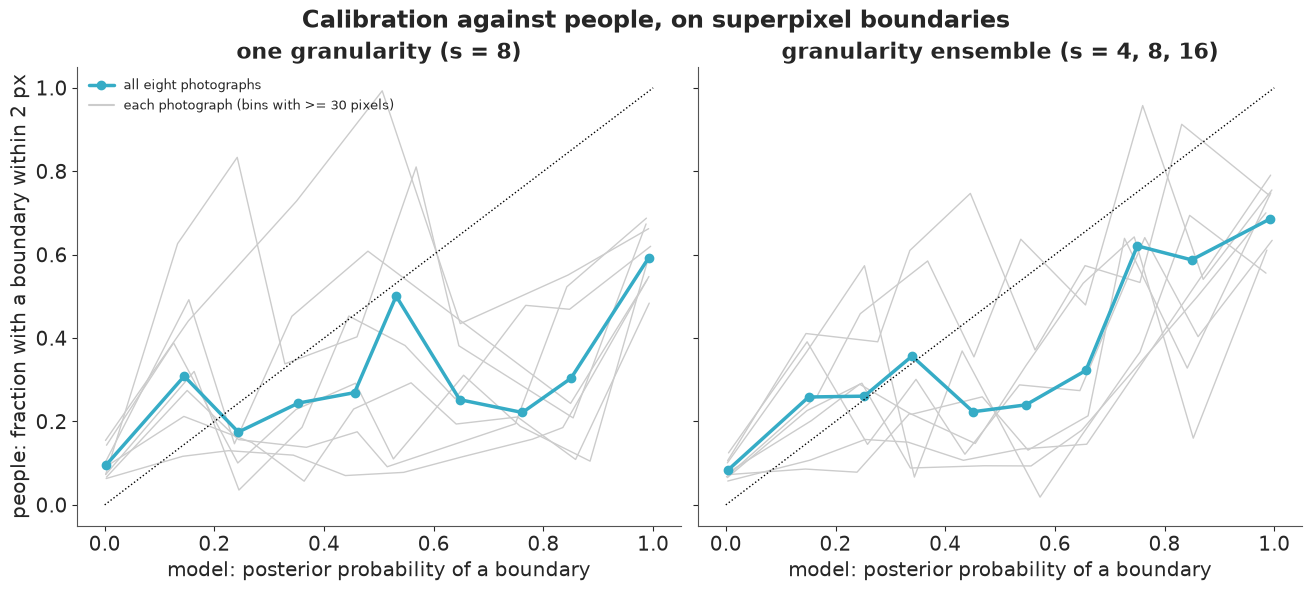

In [31]:
cal = pd.concat(cal_all)
bins = np.linspace(0, 1, 11)
fig, axs = plt.subplots(1, 2, figsize=(13, 5.8), sharey=True)
pooled = {}
for ax, key in zip(axs, ["s = 8", "ensemble"]):
    cal["bin"] = np.clip(np.digitize(cal[key], bins) - 1, 0, 9)
    for ph, dfp in cal.groupby("photo"):
        per = dfp.groupby("bin").agg(model=(key, "mean"), people=("h", "mean"), pixels=("h", "size"))
        per = per[per.pixels >= 30]
        ax.plot(per.model, per.people, "-", color="0.8", lw=1)
    pooled[key] = cal.groupby("bin").agg(model=(key, "mean"), people=("h", "mean"), pixels=("h", "size"))
    ax.plot(pooled[key].model, pooled[key].people, "-o", color="C0", lw=2.5, label="all eight photographs")
    ax.plot([0, 1], [0, 1], "k:", lw=1)
    ax.plot([], [], color="0.8", label="each photograph (bins with >= 30 pixels)")
    ax.set_xlabel("model: posterior probability of a boundary")
    ax.set_title("one granularity (s = 8)" if key == "s = 8" else "granularity ensemble (s = 4, 8, 16)")
axs[0].set_ylabel("people: fraction with a boundary within 2 px")
axs[0].legend(fontsize=9, loc="upper left")
fig.suptitle("Calibration against people, on superpixel boundaries");
print(pd.concat(pooled, axis=1).round(2).to_string())

**Calibration.** At a single granularity the pattern of the lighthouse holds across photographs:
"certain" boundaries (0.99) are drawn by 59% of people, "certain" non-boundaries by 10%, and the
intermediate probabilities are rare and do not track people. The ensemble is better on both
counts: it says "maybe" more often (the intermediate bins hold about twice as many pixels), its
curve rises from about 0.25 at low probabilities to 0.6-0.7 at high ones, and its certain boundaries
are drawn by 69% of people. It is still overconfident at the top (0.99 vs 0.69) and flat in the
middle (0.4-0.7 all map to 0.22-0.32): averaging three granularities spreads the probability but
cannot invent the judgement people use to leave a line out.

**Is the model unsure where people disagree?** Call the model *unsure* about a candidate boundary
pixel when its probability is between 0.1 and 0.9, and people *split* there when some but not all
of them drew a boundary within 2 pixels.

In [32]:
dis_rows = []
for i in TEST:
    d_i = cal[cal.photo == ids[i]]
    disputed = (d_i.h > 0) & (d_i.h < 1)          # some people drew a boundary here, some did not
    row = {("people", "split"): disputed.mean()}
    for key in ["s = 8", "ensemble"]:
        unsure = (d_i[key] > 0.1) & (d_i[key] < 0.9)
        row[(key, "unsure")] = unsure.mean()
        row[(key, "split | unsure")] = disputed[unsure].mean()
        row[(key, "split | sure")] = disputed[~unsure].mean()
    dis_rows.append(row)
dis = pd.DataFrame(dis_rows, index=pd.Index(ids[TEST], name="photo"))
dis.columns = pd.MultiIndex.from_tuples(dis.columns)
print(dis.round(2).to_string())
for key in ["s = 8", "ensemble"]:
    more = (dis[(key, "split | unsure")] > dis[(key, "split | sure")]).sum()
    print(f"{key}: people split more often where the model is unsure on {more} of {len(dis)} photographs")

       people  s = 8                             ensemble                            
        split unsure split | unsure split | sure   unsure split | unsure split | sure
photo                                                                                
100007   0.25   0.05           0.22         0.26     0.19           0.42         0.22
8068     0.13   0.07           0.45         0.11     0.12           0.29         0.11
3063     0.25   0.10           0.43         0.22     0.18           0.51         0.19
228076   0.23   0.11           0.26         0.23     0.26           0.31         0.20
97010    0.16   0.05           0.45         0.15     0.11           0.53         0.12
29030    0.25   0.07           0.23         0.25     0.18           0.29         0.24
16068    0.12   0.04           0.20         0.11     0.07           0.24         0.11
108004   0.20   0.10           0.33         0.19     0.12           0.31         0.19
s = 8: people split more often where the model is unsu

Where the ensemble is unsure, people split 24-53% of the time, against 11-24% where it is sure: more
often on every one of the eight photographs. At a single granularity this holds on six (the bear and
the car are the exceptions), and the model is unsure about far fewer pixels (4-11% of candidates
against 7-26%). So the model's uncertainty *points at* places where people disagree, but it is
uncertain in too few places and too weakly: much of what people disagree about, the model is sure of.

The picture to end with: for each photograph, the model at one granularity, the ensemble, and the
people.

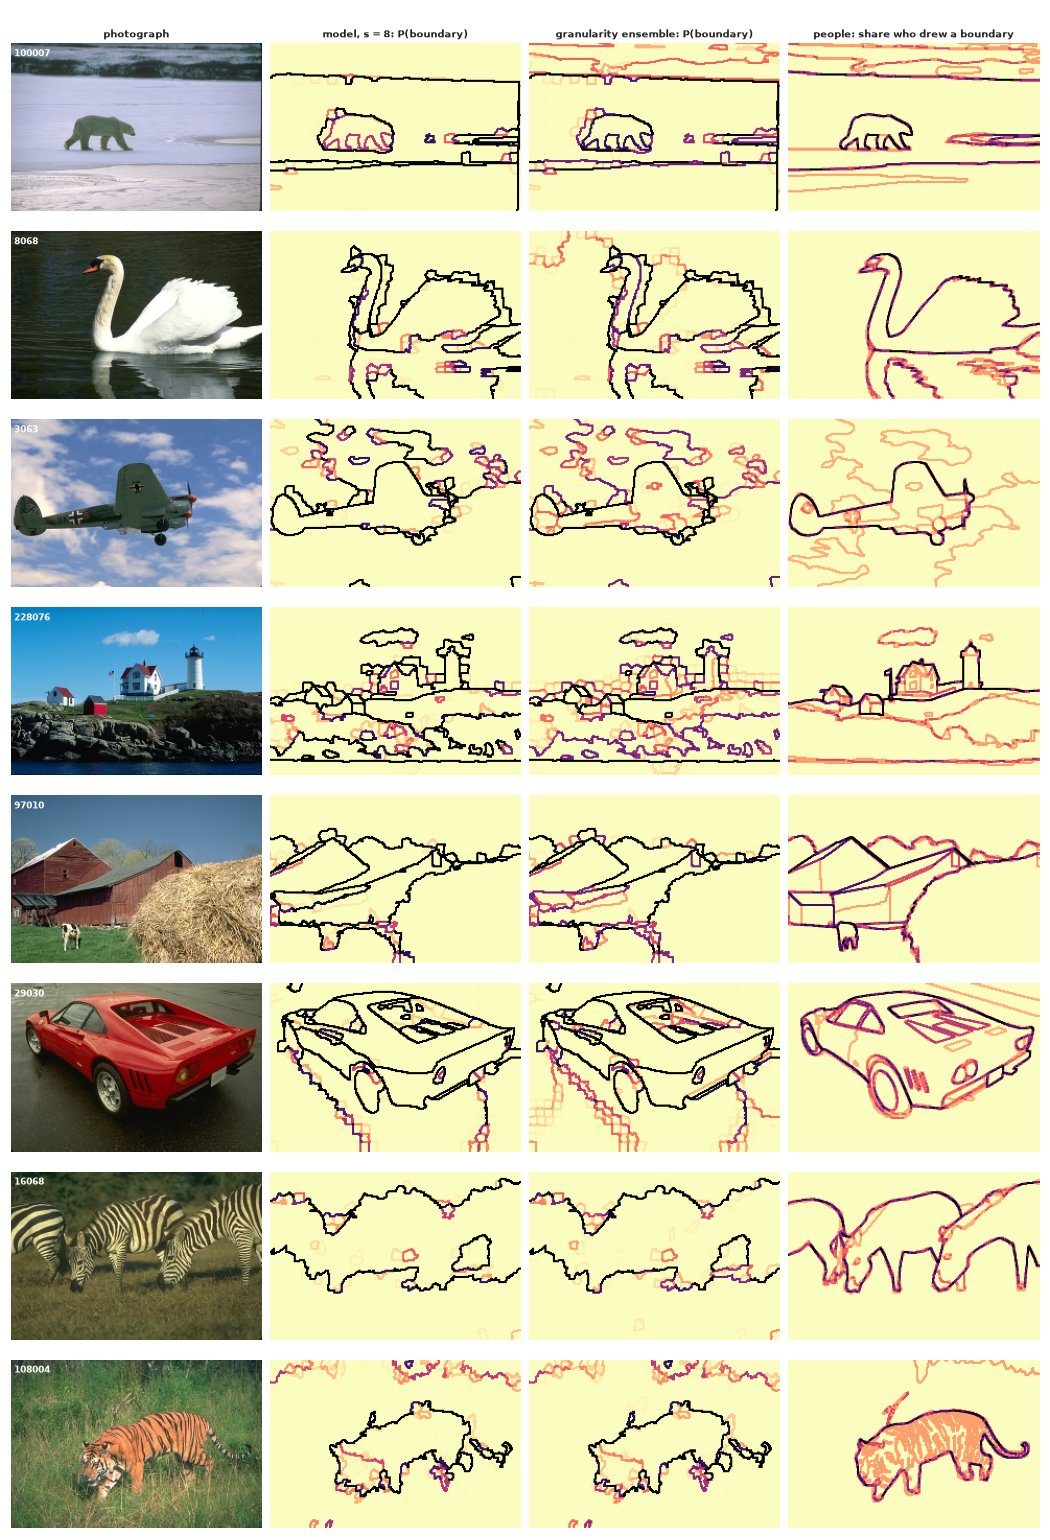

In [33]:
fig, axs = plt.subplots(len(TEST), 4, figsize=(15, 2.75 * len(TEST)), layout="none")
fig.subplots_adjust(wspace=0.03, hspace=0.06, left=0.01, right=0.99, top=0.975, bottom=0.005)
for row, i in zip(axs, TEST):
    hb_i, _ = human_maps(i)
    row[0].imshow(images[i])
    row[1].imshow(thick(edge_map(G[i], res[i]["pe"])), cmap="magma_r", vmin=0, vmax=1)
    row[2].imshow(thick(edge_map(G[i], res[i]["pe_ens"])), cmap="magma_r", vmin=0, vmax=1)
    row[3].imshow(thick(np.mean(hb_i, 0)), cmap="magma_r", vmin=0, vmax=1)
    row[0].text(3, 12, ids[i], color="w", fontsize=9, weight="bold")
    for ax in row:
        ax.axis("off")
for ax, t in zip(axs[0], ["photograph", "model, s = 8: P(boundary)", "granularity ensemble: P(boundary)",
                          "people: share who drew a boundary"]):
    ax.set_title(t, fontsize=10)
show_jpeg(fig, dpi=70)

Read across the rows: people's darkest lines are the outlines of objects (the bear, the swan, the
plane, the car, the zebras, the tiger), and the model finds most of them, except the zebras and the
tiger's tail and legs (the tiger is a rough blob). The model's extra lines are colour changes that
few people drew: reflections in the water under the swan and on the wet road under the car, cloud
edges around the plane, the rocks below the lighthouse, patches of grass around the tiger. The
ensemble adds finer, less certain lines (orange), some of which people drew too (cloud edges around
the plane) and many of which they did not.

## Summary

* **Segmentation is clustering with an unknown number of clusters, plus space.** A Dirichlet-process
  (Chinese restaurant) prior leaves K open; a Potts prior on neighbouring superpixels makes segments
  coherent. On a synthetic image with known truth, the spatial prior removed the speckle and cut the
  distance to the truth by a factor of five.
* **Use the right sampler for the unknown.** NUTS on a marginalised stick-breaking mixture gave
  label switching (harmless), chains in different modes and a binding truncation (not harmless).
  Integrating the cluster parameters out and sampling the partition itself, with Swendsen-Wang block
  moves, parallel tempering and an annealed start, gave agreeing chains on six of eight photographs,
  after checking the sampler against exact enumeration. A chain started in one segment sat 1,259 nats
  below the posterior without a single warning.
* **Summaries must be label-invariant**: co-assignment and boundary probabilities, the posterior of
  K, and point estimates that minimise Binder or VI loss rather than the MAP.
* **Judge the spatial coupling with data, not with the prior.** The partition prior alone collapses
  into one segment at $\beta = 0.01$, yet $\beta = 1$ is what works once the likelihood is in: its
  strength only means something relative to the likelihood. $\beta$ was chosen on training
  photographs.
* **The posterior's uncertainty is not people's.** At fixed settings the posterior is nearly certain
  about every boundary and every K, while five people differ by a factor of three in how finely they
  divide a photograph. Its boundary probabilities are not calibrated to people, and as a boundary
  detector it does no better than raw colour contrast. Averaging over granularity improves both
  calibration and F a little, and makes the model unsure where people disagree on all eight
  photographs, but the largest disagreements (a zebra's outline, reflections) are about what an
  object is, which colour statistics cannot know.
* **Show partitions as partitions**: boundary-probability maps, "click a pixel" co-assignment maps,
  K with a representative segmentation per value, and grids or animations of posterior draws (each
  segment painted in its mean colour, so that no arbitrary label colours appear).

## Try it yourself

1. **Learn $\beta$ properly.** Add an exchange-algorithm step (Murray, Ghahramani & MacKay 2006) for
   $\beta$: propose $\beta'$, simulate an auxiliary partition from the prior at $\beta'$ with the
   sampler's `lw=0` mode, and accept with the ratio in which the Potts normalising constants cancel.
   Where does the posterior of $\beta$ sit, and does it agree with the value chosen on training
   photographs? (Expect trouble near the prior's phase transition: the auxiliary draw must be exact
   enough.)
2. **Better features.** The zebras defeated colour and within-superpixel texture. Add a feature that
   sees stripes (for example the dominant orientation and strength of the lightness gradient in a
   window around each superpixel), refit, and check the F-measure and the calibration on the test
   photographs, choosing any new setting on the training photographs only.
3. **A hierarchy of granularities.** Instead of averaging three independent fits, fit one model in
   which the segments at scale $s = 16$ are unions of the segments at $s = 4$ (a nested partition,
   in the spirit of the hierarchical segmentations of Arbelaez et al. 2011), so that every draw is a
   whole hierarchy. Is the boundary probability of the hierarchy better calibrated against people
   than the ensemble's?